In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\data.csv")

In [3]:
# Display first 5 rows
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [3]:
#shape
print("Shape of dataset:", df.shape)
# Data types and null values
df.info()
# Statistical summary for numerical columns
df.describe()

Shape of dataset: (9712, 8)
<class 'pandas.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   str    
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   str    
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   str    
 7   Urban_or_Rural                     9712 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 540.7 KB


,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [4]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [4]:
#check missing values
df.isnull().sum() #counts missing values
df['Health_Impacts'] = df['Health_Impacts'].fillna("No Heatlth Issue") #Handling Null values with No Health Issue 

In [5]:
df.isnull().sum() #no null values 

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [7]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [6]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if needed
df.drop_duplicates(inplace=True)

Duplicate rows: 44


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


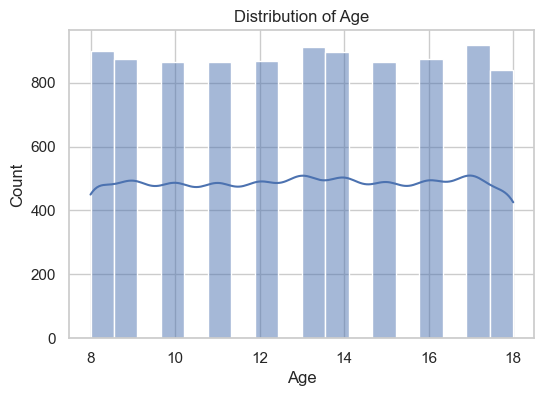

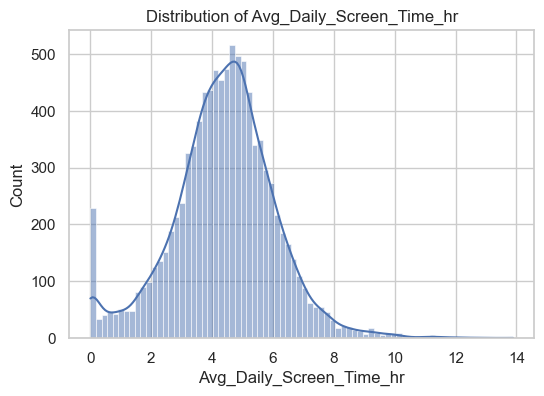

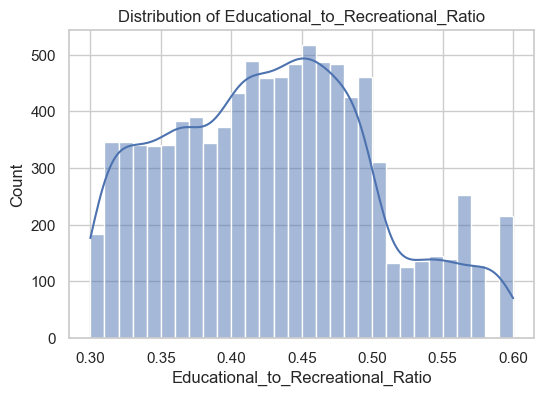

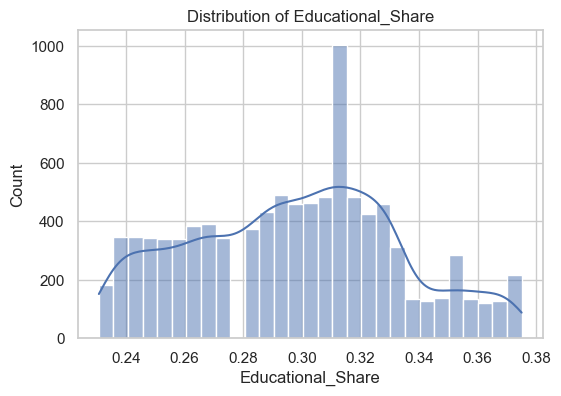

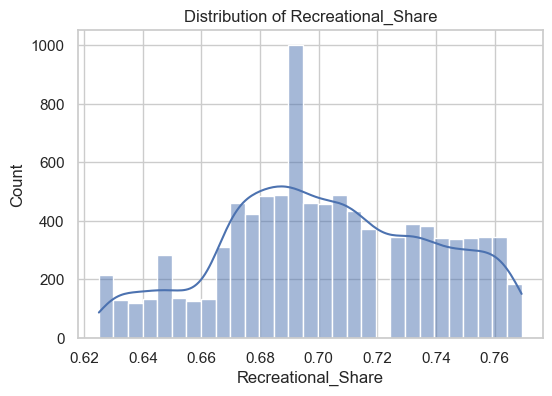

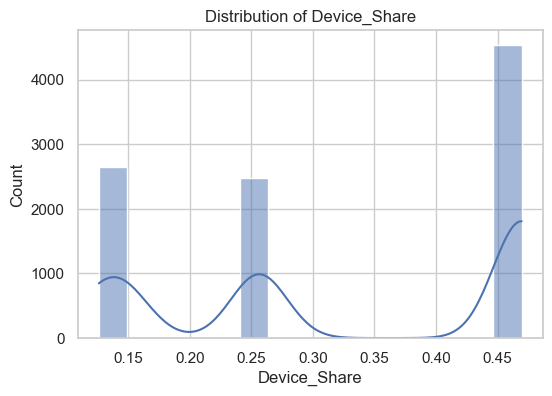

In [65]:
import numpy as np
#Numerical Columns Distribution
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [82]:
import warnings
warnings.filterwarnings('ignore')

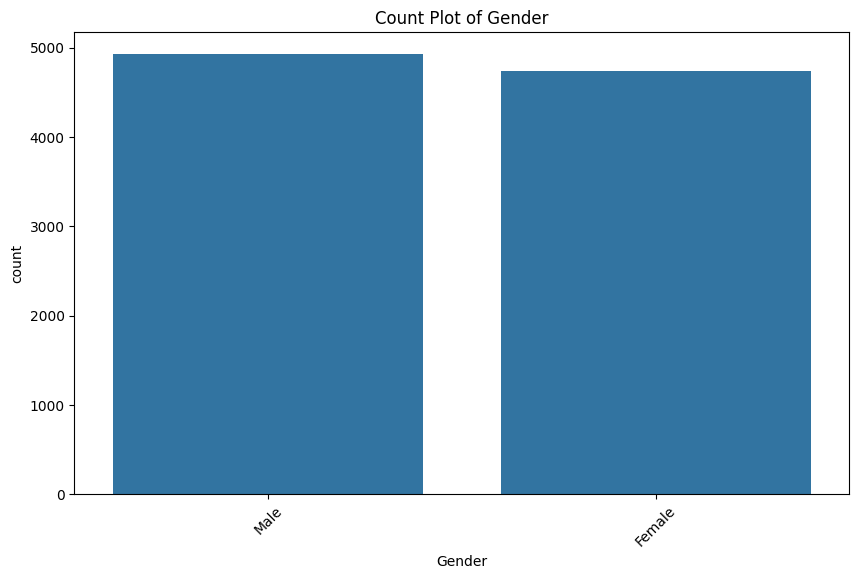

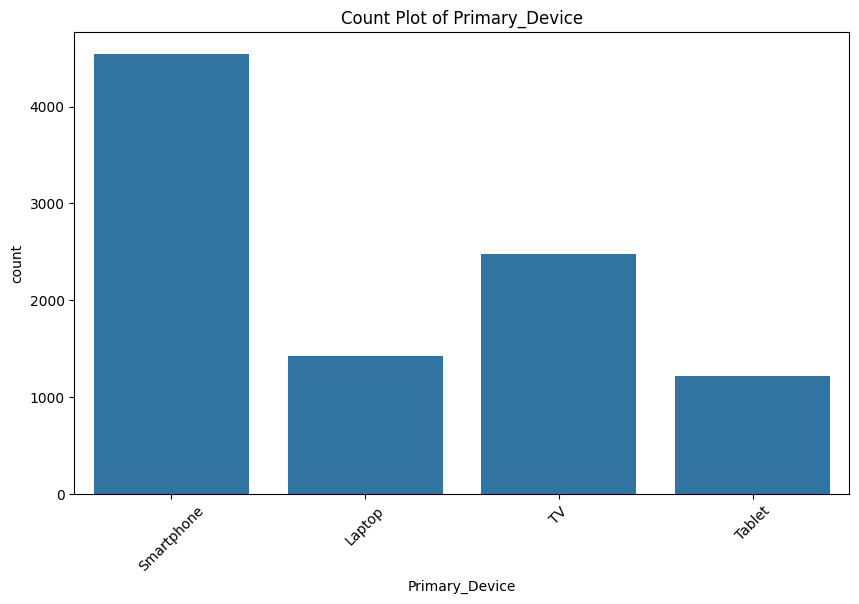

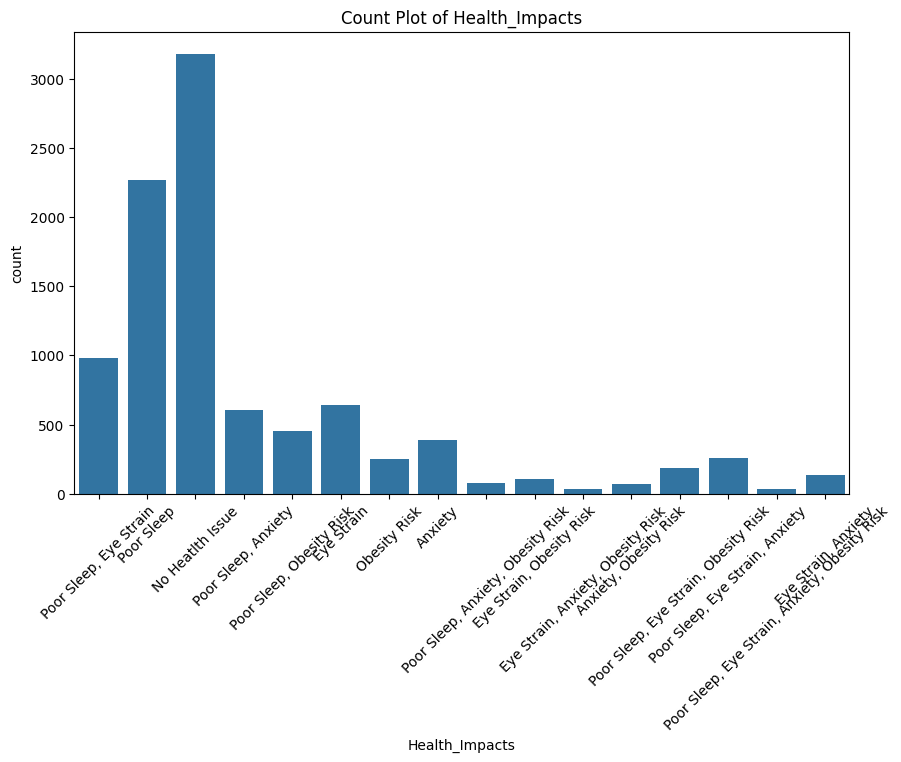

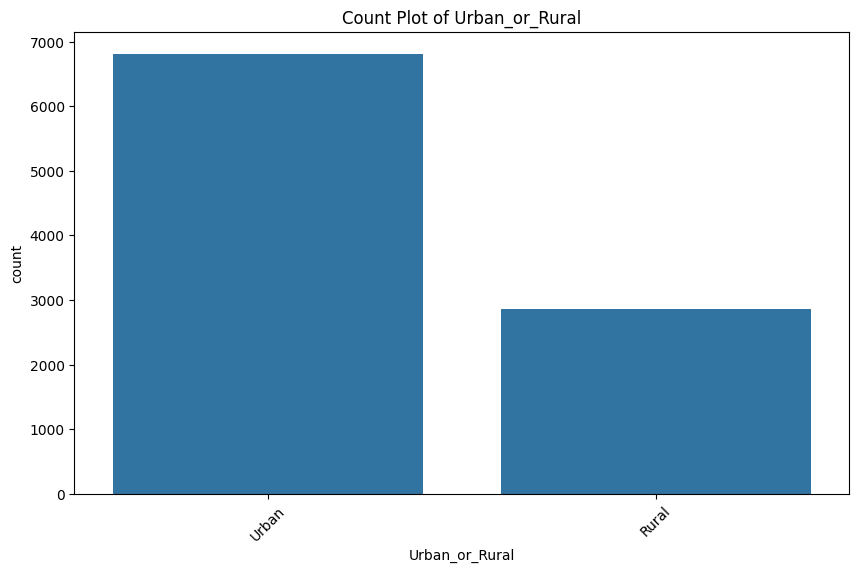

In [12]:
#Categorical Columns Count
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10,6))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.show()


In [16]:
# Create Age Bands
def age_band(age):
    if age <= 10:
        return "Young Kids (8-10)"
    elif age <= 13:
        return "Pre-Teens (11-13)"
    else:
        return "Teens (14-18)"

df["Age_Band"] = df["Age"].apply(age_band)

# Check
df["Age_Band"].value_counts()

Age_Band
Teens (14-18)        4390
Pre-Teens (11-13)    2640
Young Kids (8-10)    2638
Name: count, dtype: int64

In [15]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859


In [12]:
df["Educational_Share"] = (
    df["Educational_to_Recreational_Ratio"] /
    (1 + df["Educational_to_Recreational_Ratio"])
)

In [17]:
df["Recreational_Share"] = 1 - df["Educational_Share"]

In [18]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share,Recreational_Share
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775,0.704225
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769,0.769231
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424,0.757576
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576,0.719424
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859,0.671141


In [20]:
# Assume higher screen time likely on weekends (proxy logic)
df["Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Weekend" if x > df["Avg_Daily_Screen_Time_hr"].median() else "Weekday"
)

df["Day_Type"].value_counts()

Day_Type
Weekday    4844
Weekend    4824
Name: count, dtype: int64

In [21]:
df.head(

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share,Recreational_Share,Day_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775,0.704225,Weekday
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769,0.769231,Weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424,0.757576,Weekday
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576,0.719424,Weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859,0.671141,Weekend


In [26]:
mean_val = df["Avg_Daily_Screen_Time_hr"].mean()
median_val = df["Avg_Daily_Screen_Time_hr"].median()

print("Mean:", mean_val)
print("Median:", median_val)

Mean: 4.367780306164667
Median: 4.44


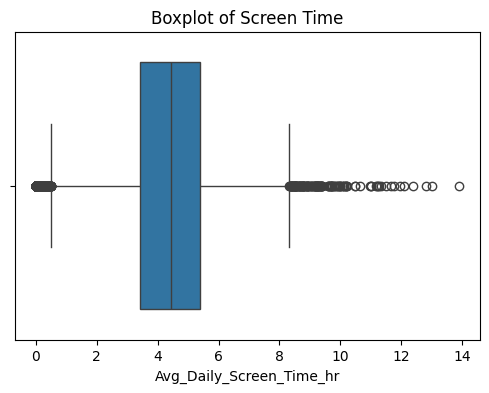

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Avg_Daily_Screen_Time_hr"])
plt.title("Boxplot of Screen Time")
plt.show()

In [28]:
device_share = (
    df["Primary_Device"]
    .value_counts(normalize=True)
    .rename("Device_Share")
)

device_share

Primary_Device
Smartphone    0.469590
TV            0.256309
Laptop        0.148014
Tablet        0.126086
Name: Device_Share, dtype: float64

In [29]:
device_share_map = df["Primary_Device"].value_counts(normalize=True)
df["Device_Share"] = df["Primary_Device"].map(device_share_map)

,Primary_Device,Device_Share
0,Smartphone,0.469590
1,Laptop,0.148014
2,TV,0.256309
3,Laptop,0.148014
4,Smartphone,0.469590


In [31]:
df.head(10)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share,Recreational_Share,Day_Type,Device_Share
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775,0.704225,Weekday,0.469590
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769,0.769231,Weekend,0.148014
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424,0.757576,Weekday,0.256309
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576,0.719424,Weekday,0.148014
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859,0.671141,Weekend,0.469590
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban,Teens (14-18),0.305556,0.694444,Weekend,0.469590
6,17,Male,2.97,TV,False,0.48,No Heatlth Issue,Rural,Teens (14-18),0.324324,0.675676,Weekday,0.256309
7,10,Male,2.74,TV,True,0.54,No Heatlth Issue,Urban,Young Kids (8-10),0.350649,0.649351,Weekday,0.256309
8,14,Male,4.61,Laptop,True,0.36,"Poor Sleep, Anxiety",Rural,Teens (14-18),0.264706,0.735294,Weekend,0.148014
9,18,Male,3.24,Tablet,True,0.48,"Poor Sleep, Obesity Risk",Urban,Teens (14-18),0.324324,0.675676,Weekday,0.126086


In [34]:
# Create device nature column
def device_nature(device):
    portable_devices = ["Smartphone", "Tablet", "Laptop", "Handheld Game Console"]
    
    if device in portable_devices:
        return "Portable"
    else:
        return "Wall-Mounted"

df["Device_Nature"] = df["Primary_Device"].apply(device_nature)


In [35]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share,Recreational_Share,Day_Type,Device_Share,Device_Nature
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775,0.704225,Weekday,0.469590,Portable
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769,0.769231,Weekend,0.148014,Portable
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424,0.757576,Weekday,0.256309,Wall-Mounted
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576,0.719424,Weekday,0.148014,Portable
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859,0.671141,Weekend,0.469590,Portable


In [36]:
df["Device_Nature"].value_counts()

Device_Nature
Portable        7190
Wall-Mounted    2478
Name: count, dtype: int64

In [39]:
# Create device nature column
def device_nature(device):
    portable_devices = ["Smartphone", "Tablet", "Laptop", "Handheld Game Console"]
    
    if device in portable_devices:
        return "Portable"
    else:
        return "Wall-Mounted"

df["Device_Nature"] = df["Primary_Device"].apply(device_nature)



In [38]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Educational_Share,Recreational_Share,Day_Type,Device_Share,Device_Nature
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teens (14-18),0.295775,0.704225,Weekday,0.469590,Portable
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens (11-13),0.230769,0.769231,Weekend,0.148014,Portable
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Teens (14-18),0.242424,0.757576,Weekday,0.256309,Wall-Mounted
3,15,Female,1.21,Laptop,False,0.39,No Heatlth Issue,Urban,Teens (14-18),0.280576,0.719424,Weekday,0.148014,Portable
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens (11-13),0.328859,0.671141,Weekend,0.469590,Portable


In [81]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))

Numerical Columns: ['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio', 'Educational_Share', 'Recreational_Share', 'Device_Share']
Categorical Columns: ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural', 'Age_Band', 'Day_Type', 'Device_Nature']


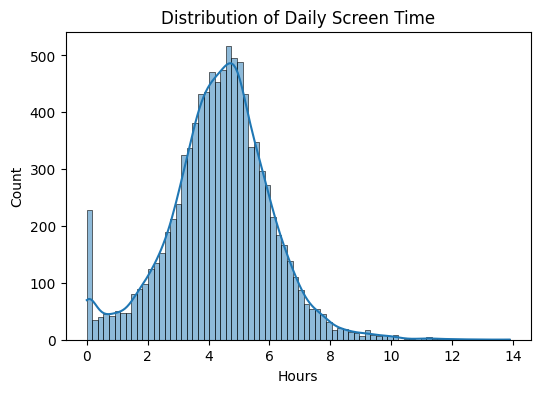

In [40]:
#univariate numerical
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Avg_Daily_Screen_Time_hr"], kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

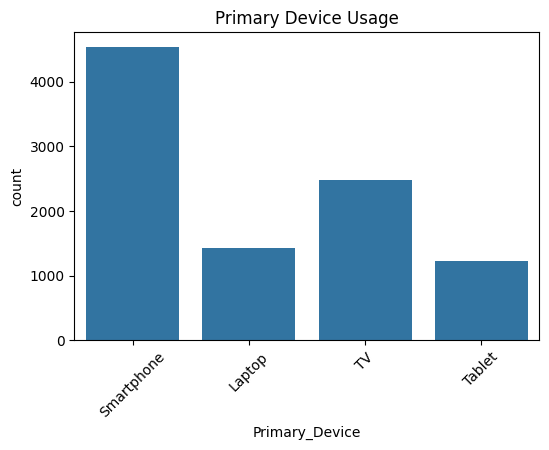

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Primary_Device")
plt.title("Primary Device Usage")
plt.xticks(rotation=45)
plt.show()

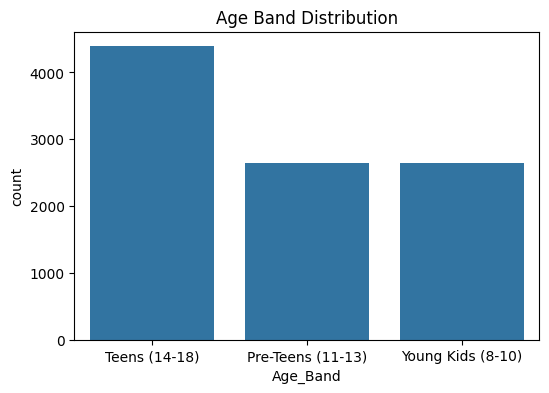

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age_Band")
plt.title("Age Band Distribution")
plt.show()

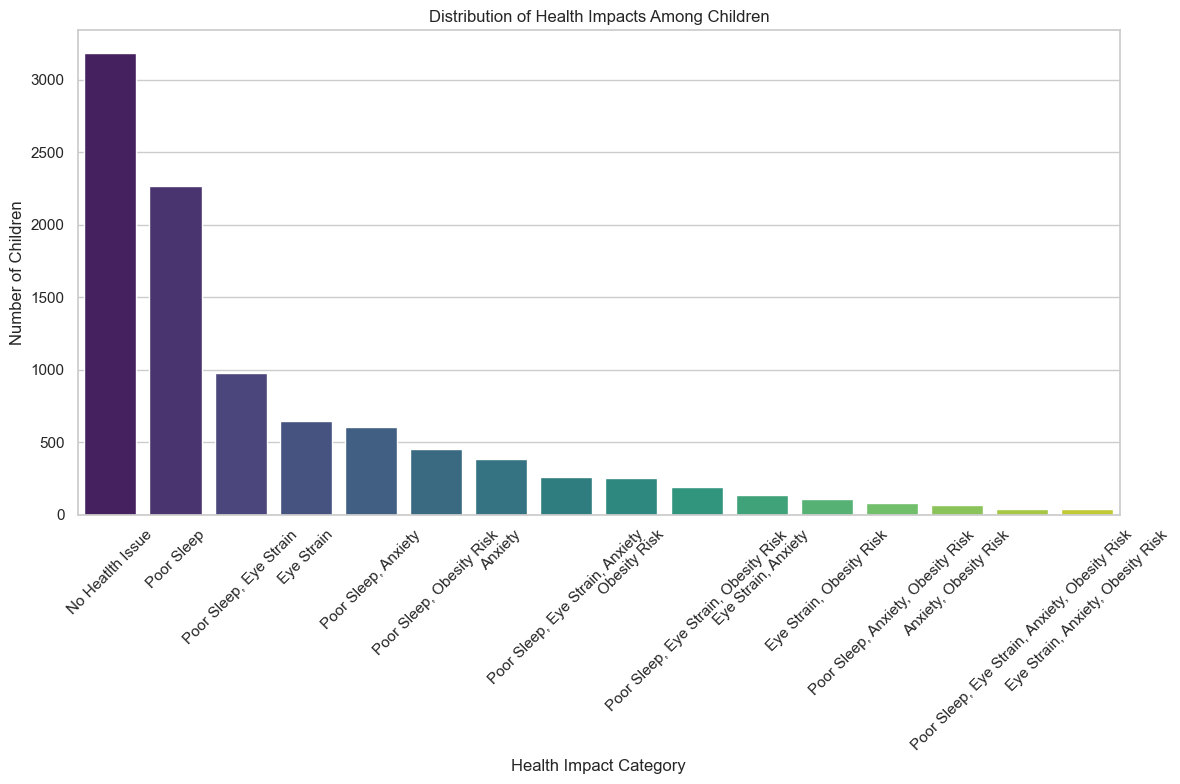

In [83]:


# set style
sns.set(style="whitegrid")

plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    x="Health_Impacts",
    order=df["Health_Impacts"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Health Impacts Among Children")
plt.xlabel("Health Impact Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#bivariate

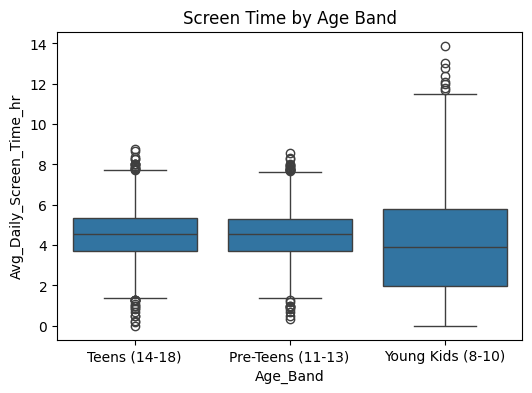

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Age_Band", y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time by Age Band")
plt.show()

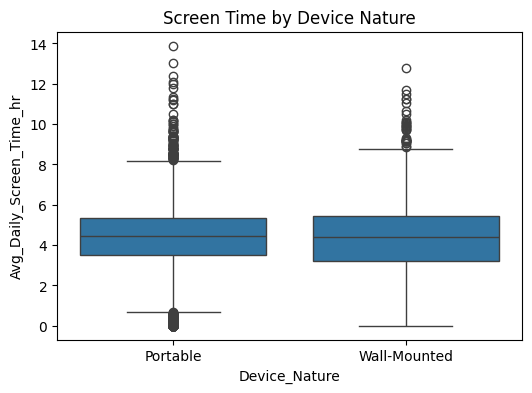

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Device_Nature", y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time by Device Nature")
plt.show()

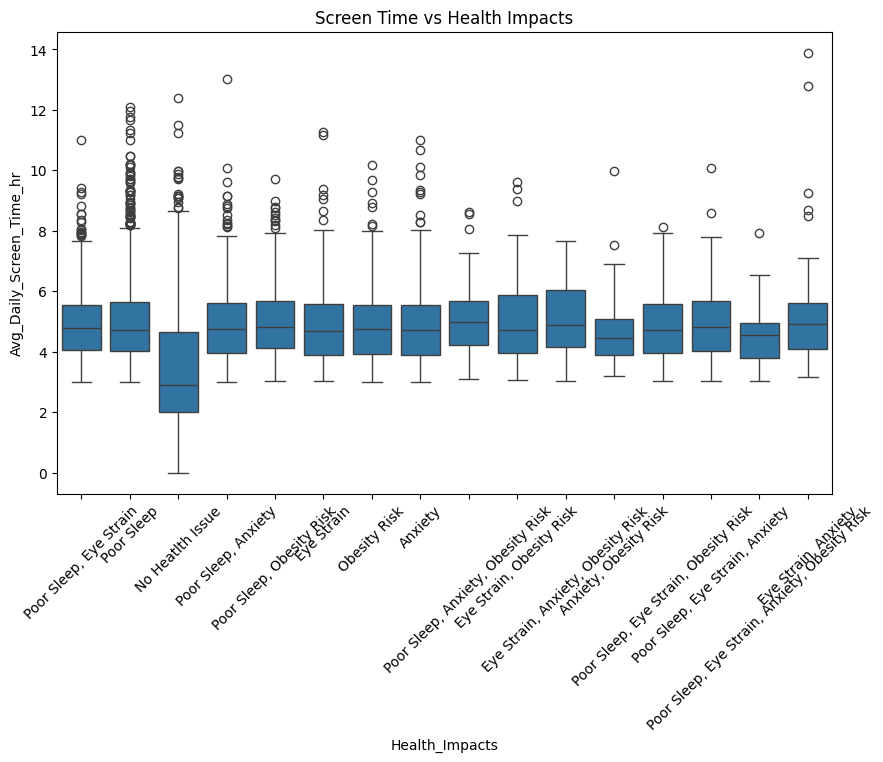

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Health_Impacts", y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time vs Health Impacts")
plt.xticks(rotation=45)
plt.show()

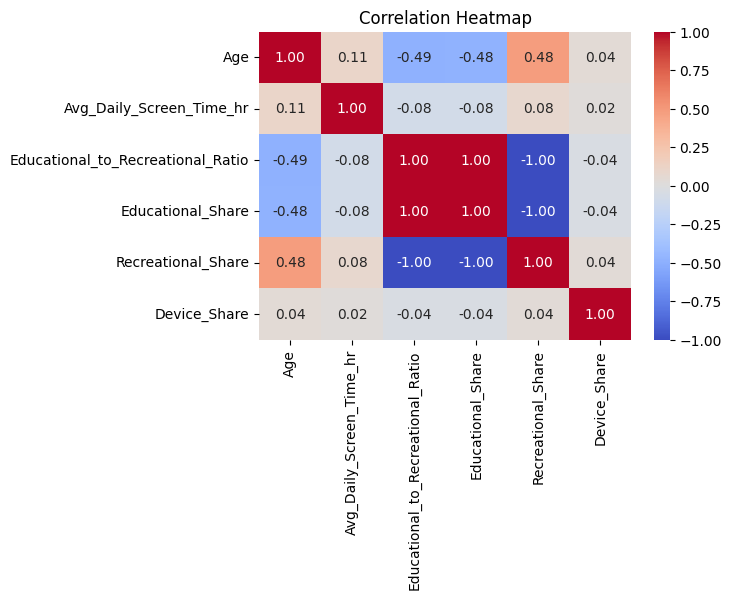

In [55]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [74]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))

Numerical Columns: ['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio', 'Educational_Share', 'Recreational_Share', 'Device_Share']
Categorical Columns: ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural', 'Age_Band', 'Day_Type', 'Device_Nature']


In [ ]:
# NUMERICAL COLUMNS → HISTOGRAM (Distribution)

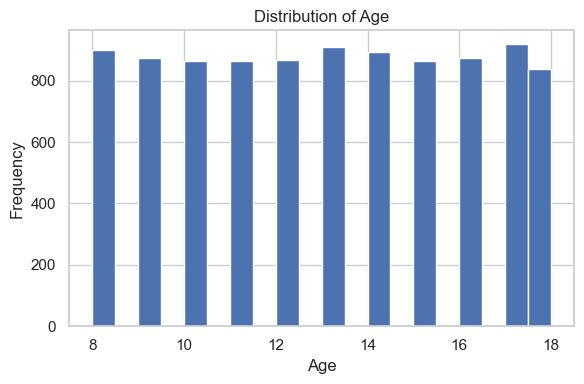

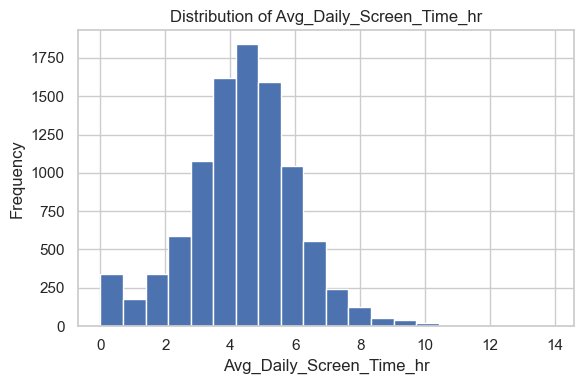

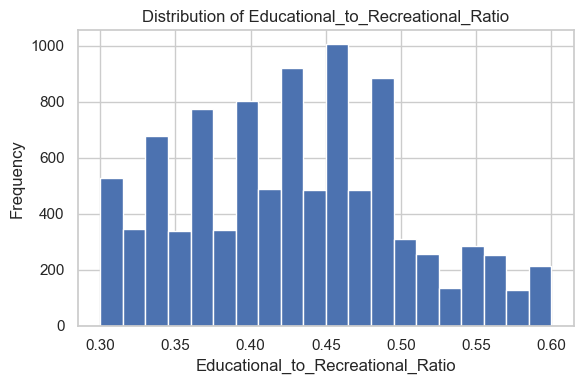

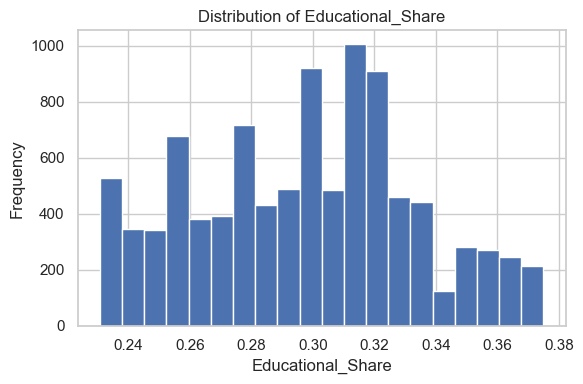

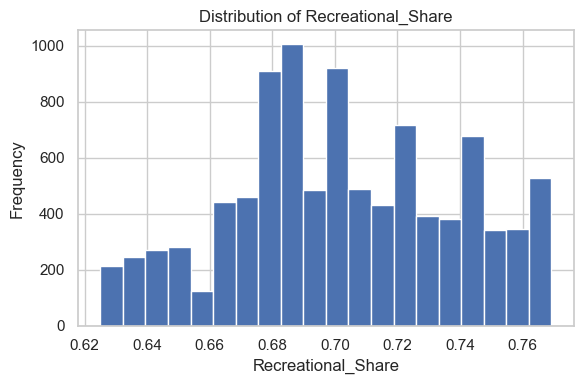

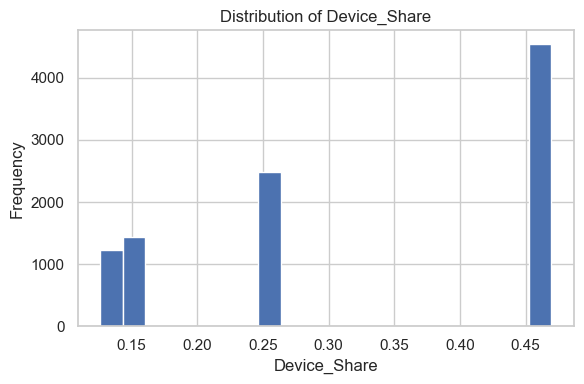

In [75]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


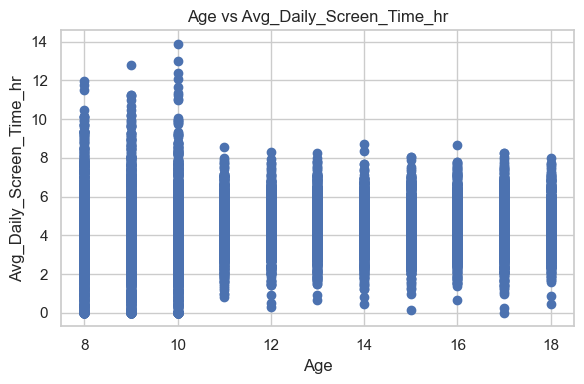

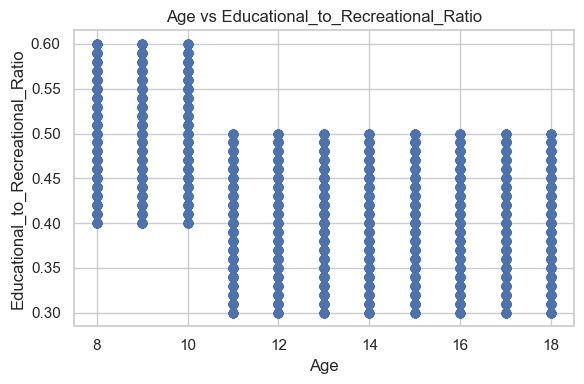

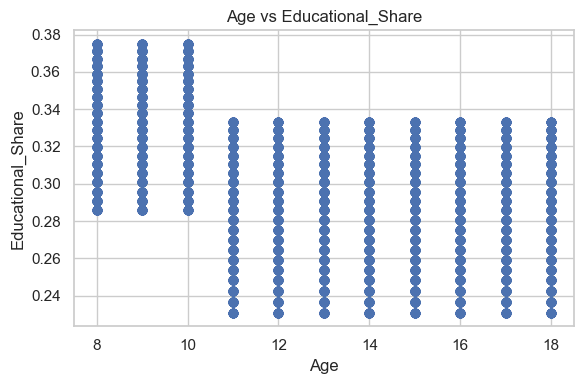

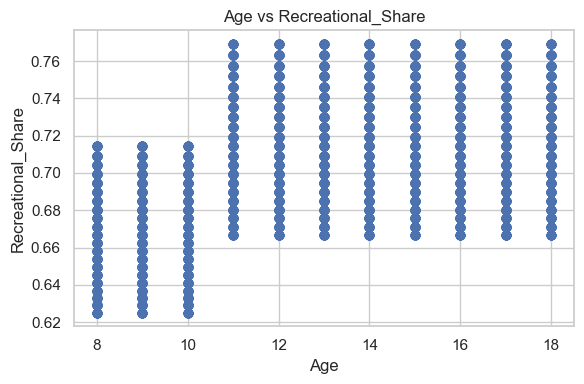

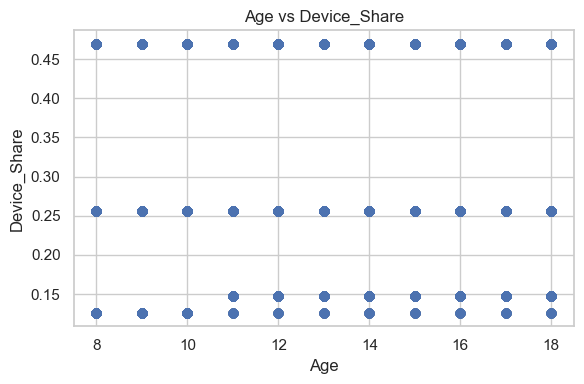

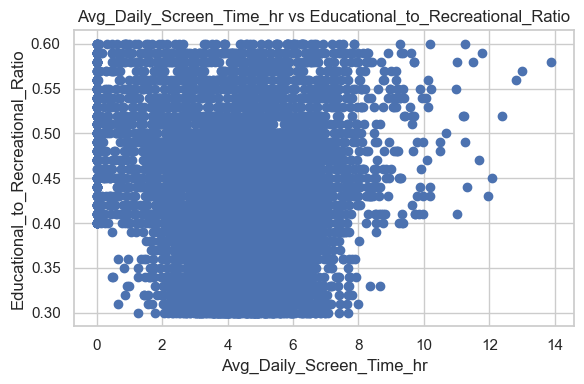

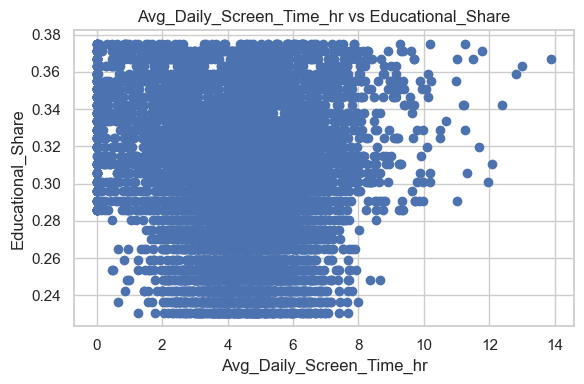

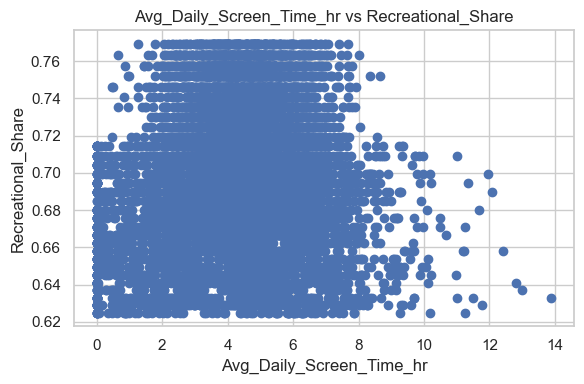

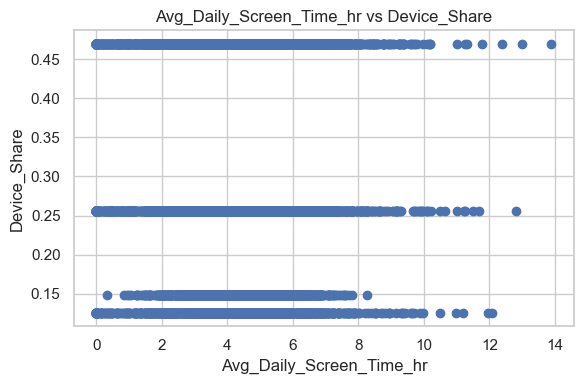

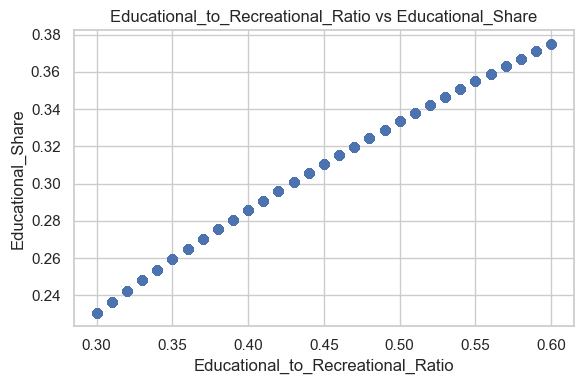

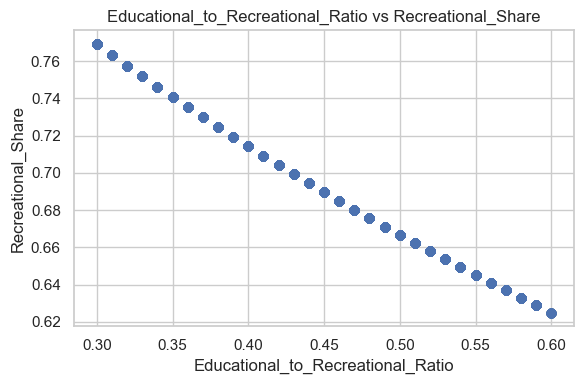

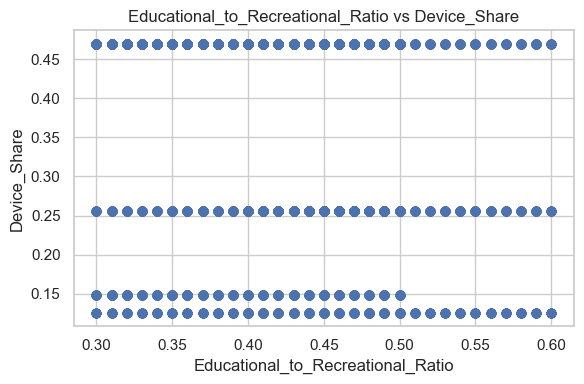

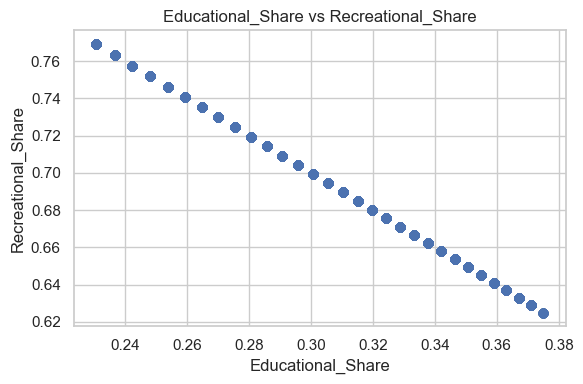

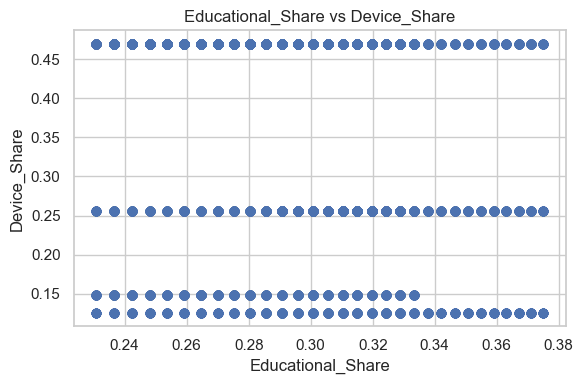

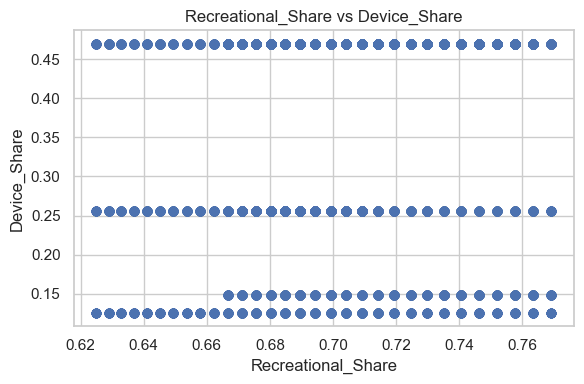

In [77]:
#  NUMERICAL vs NUMERICAL → SCATTER PLOTS

for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        plt.figure(figsize=(6,4))
        plt.scatter(df[numerical_cols[i]], df[numerical_cols[j]])
        plt.xlabel(numerical_cols[i])
        plt.ylabel(numerical_cols[j])
        plt.title(f"{numerical_cols[i]} vs {numerical_cols[j]}")
        plt.tight_layout()
        plt.show()

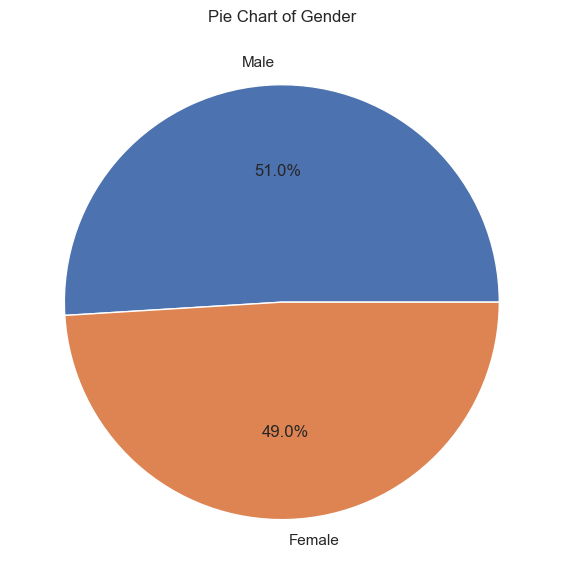

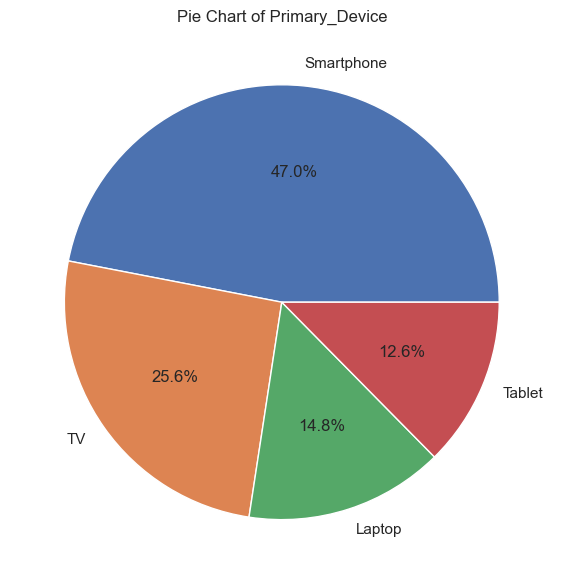

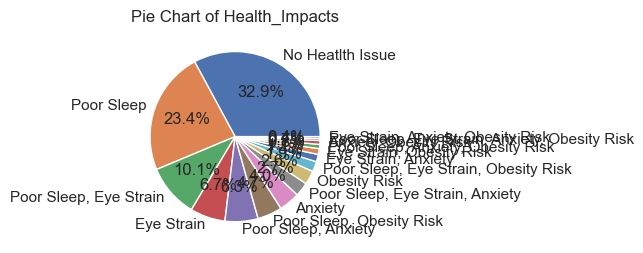

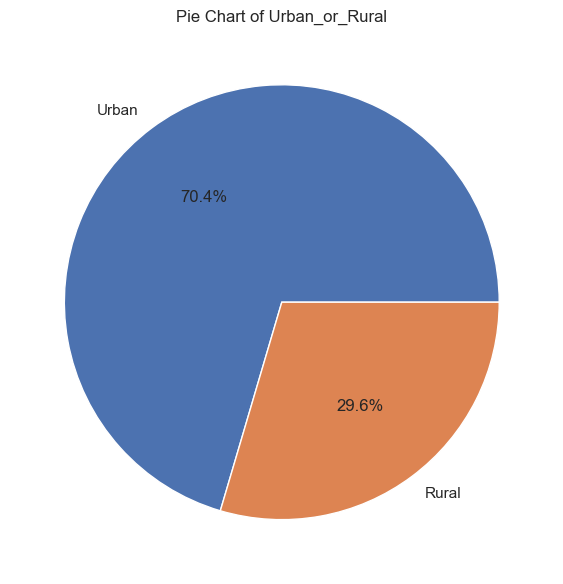

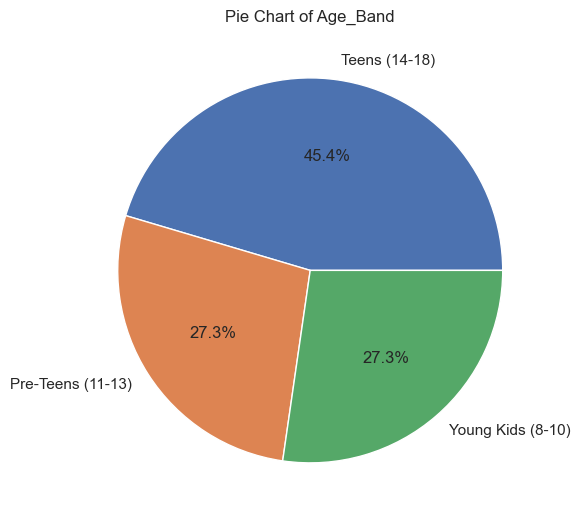

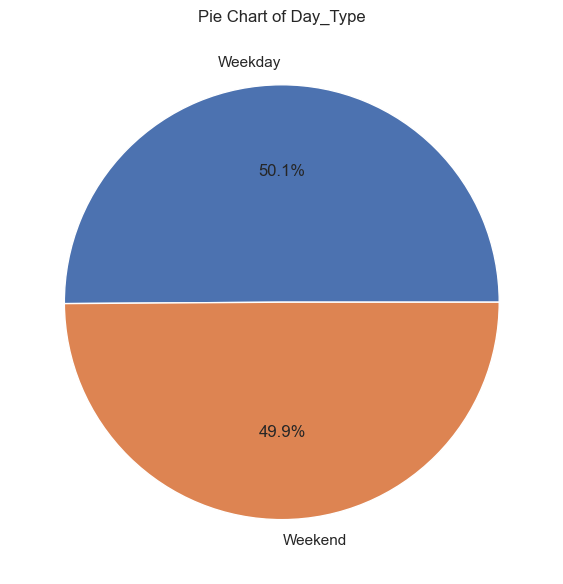

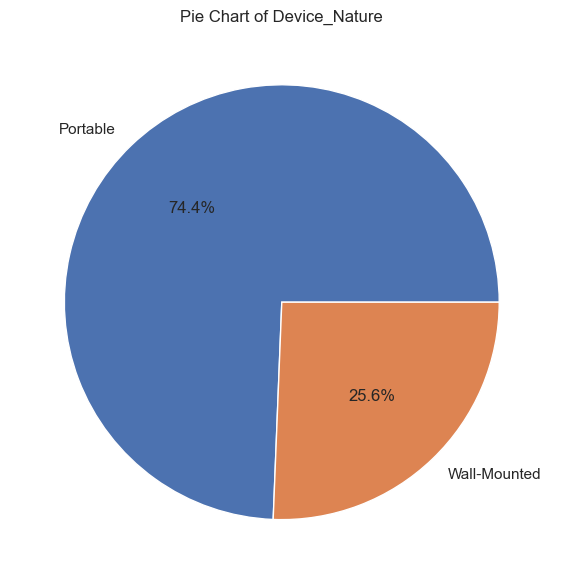

In [76]:

#  CATEGORICAL COLUMNS → PIE CHART

for col in categorical_cols:
    plt.figure(figsize=(6,6))
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    plt.title(f"Pie Chart of {col}")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


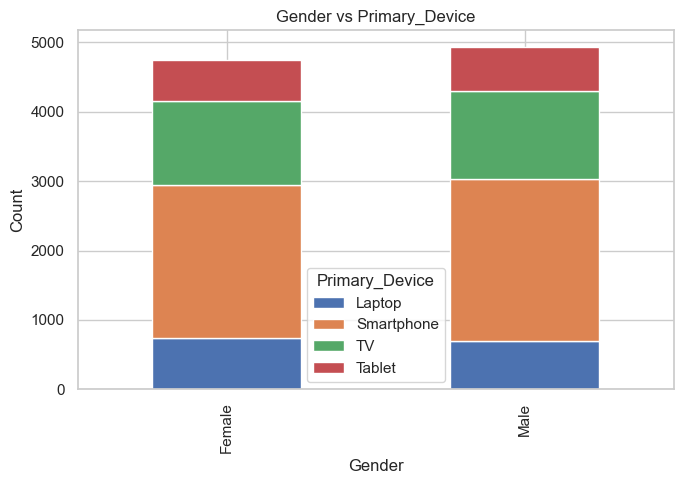

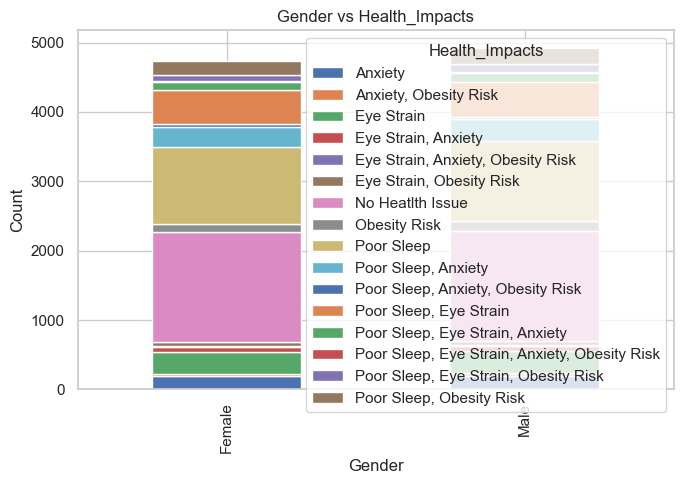

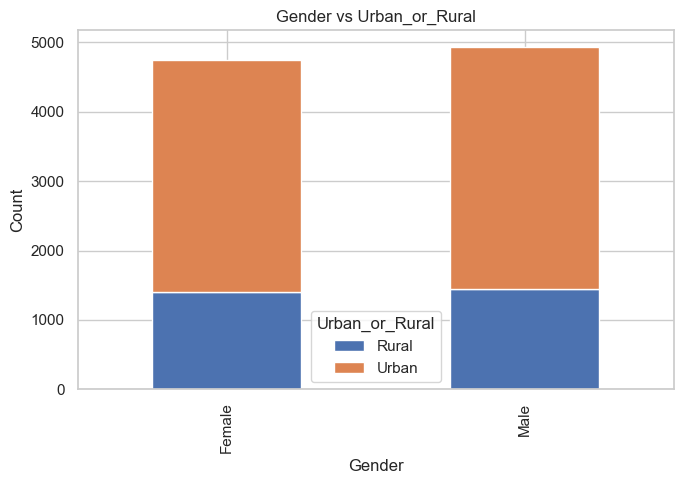

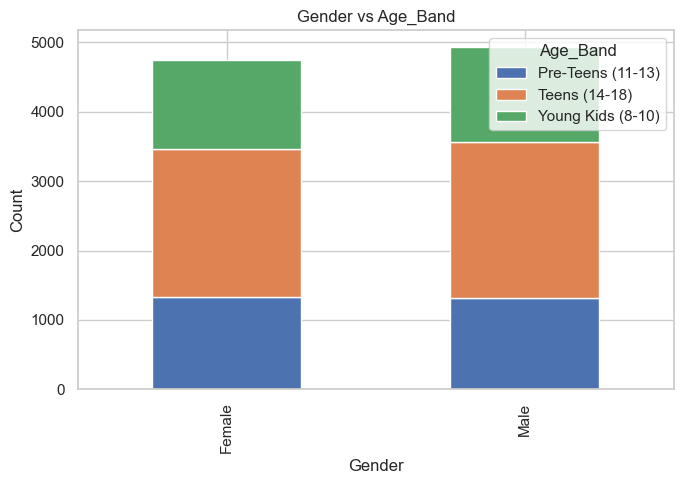

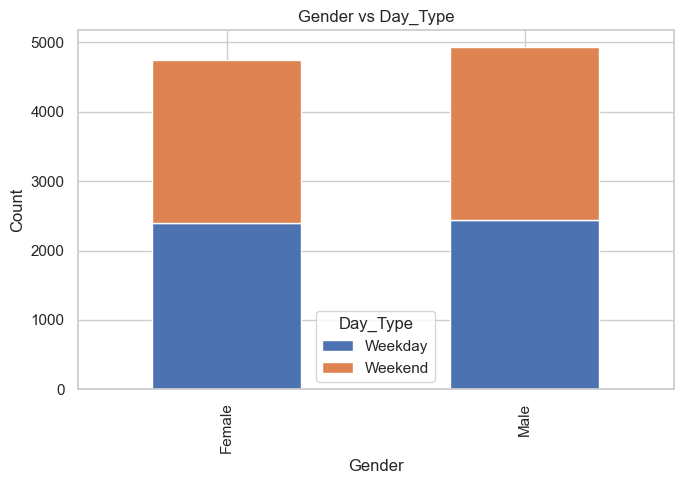

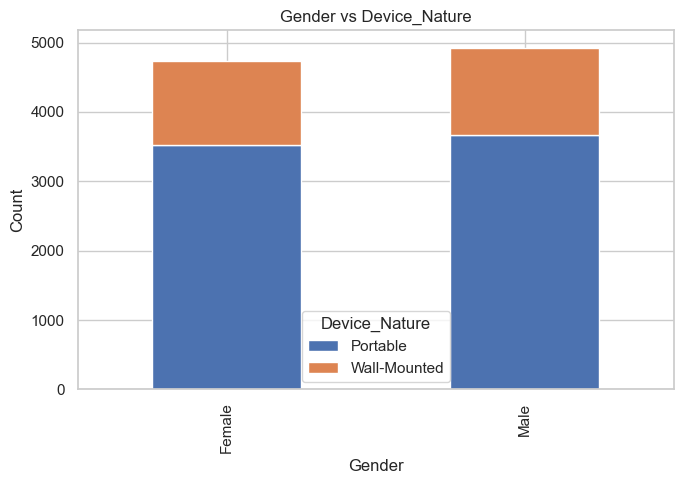

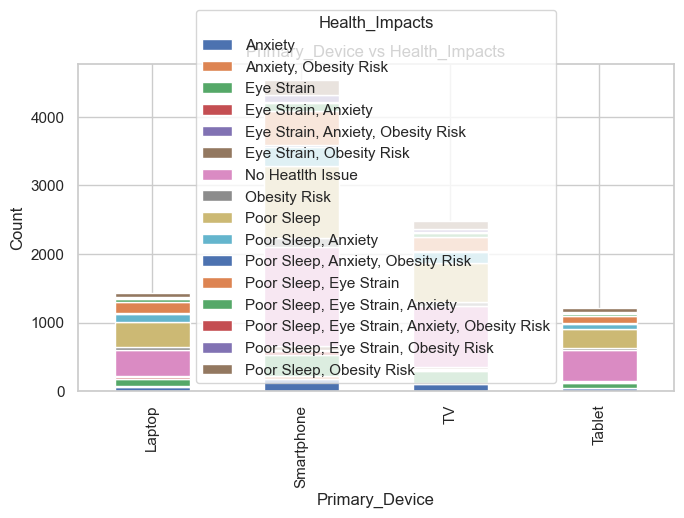

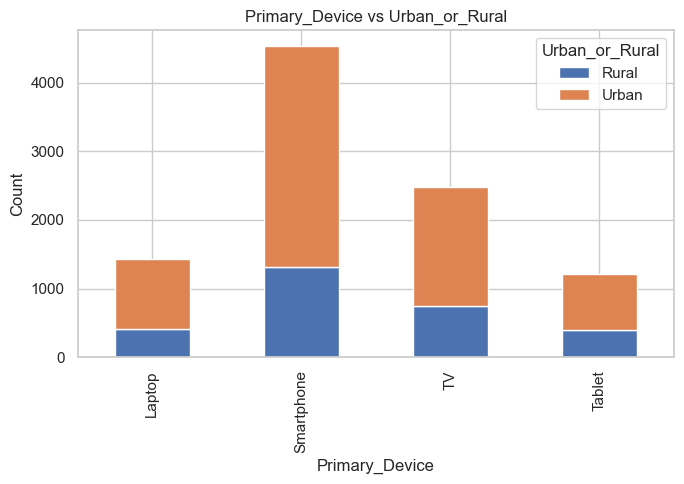

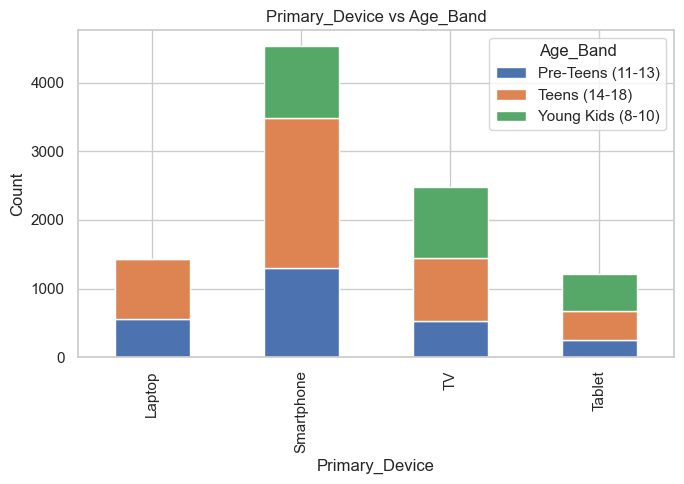

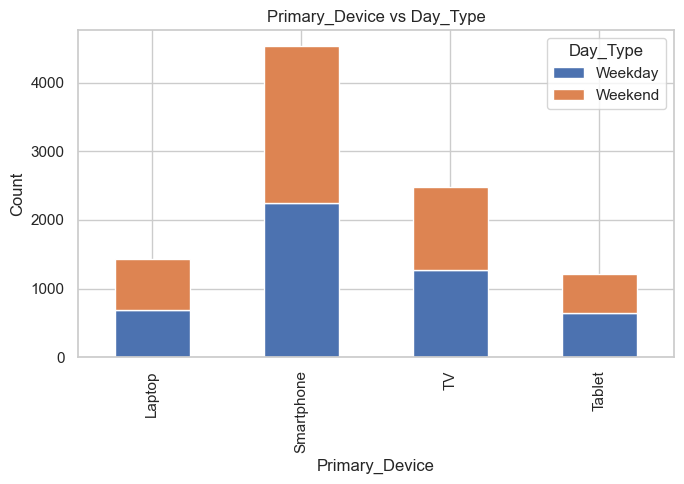

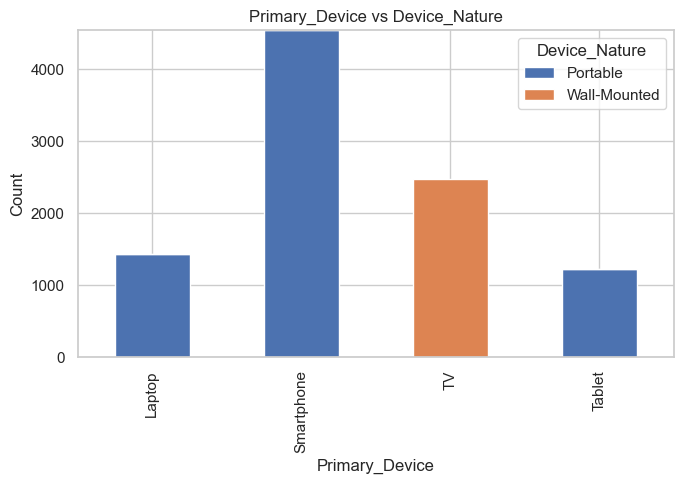

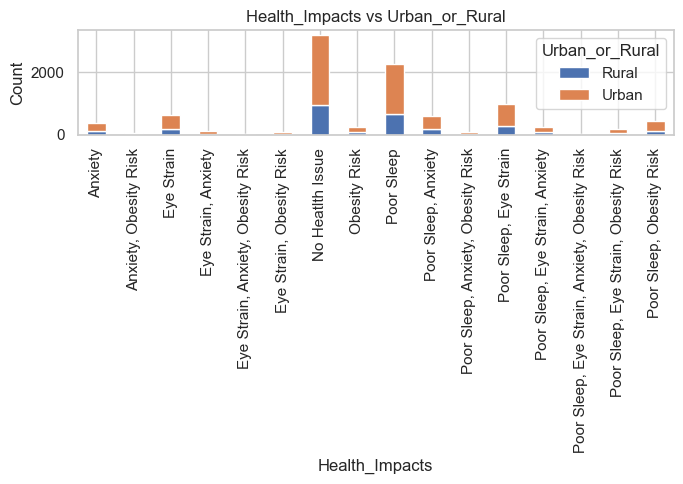

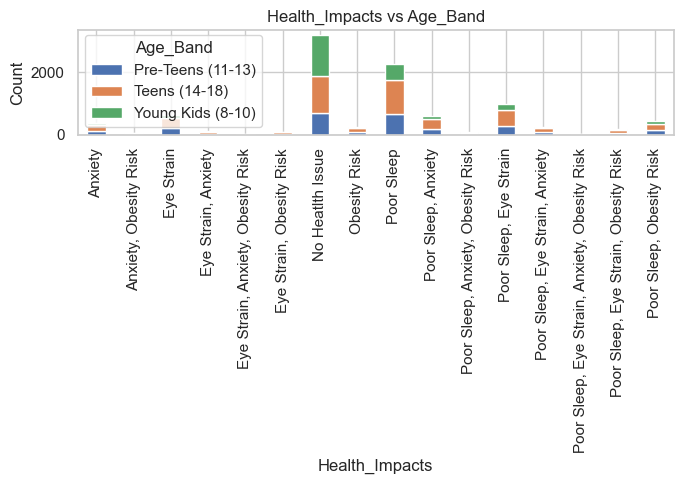

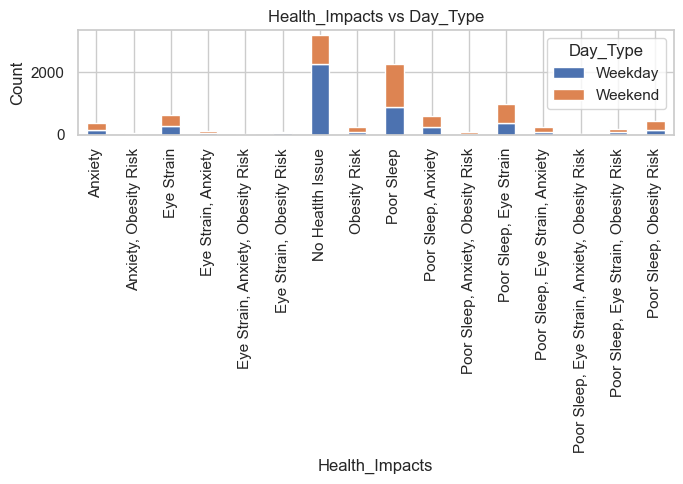

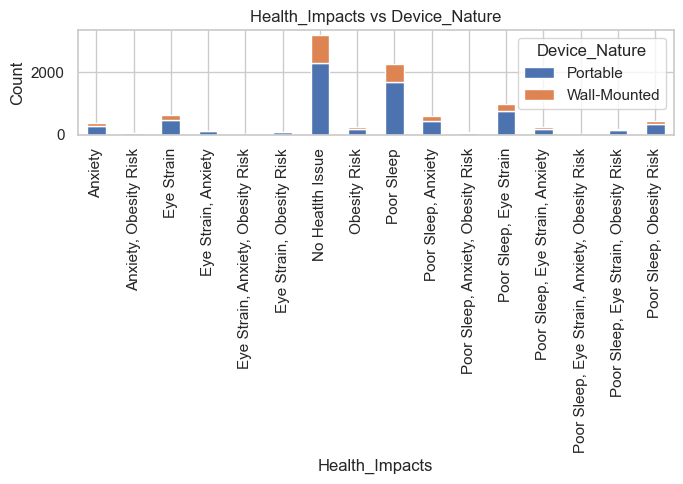

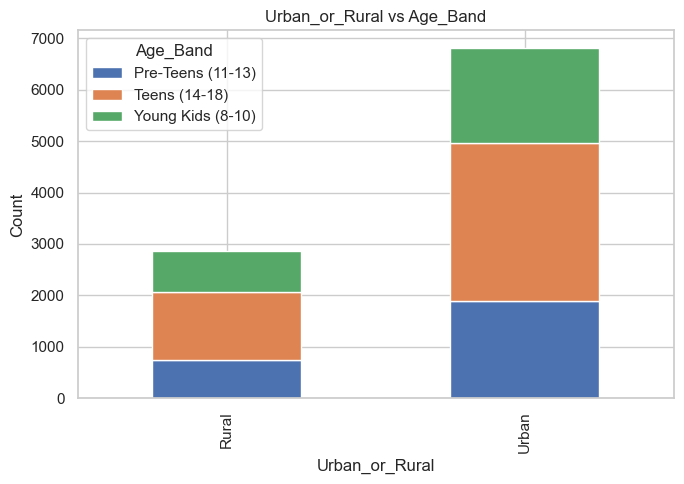

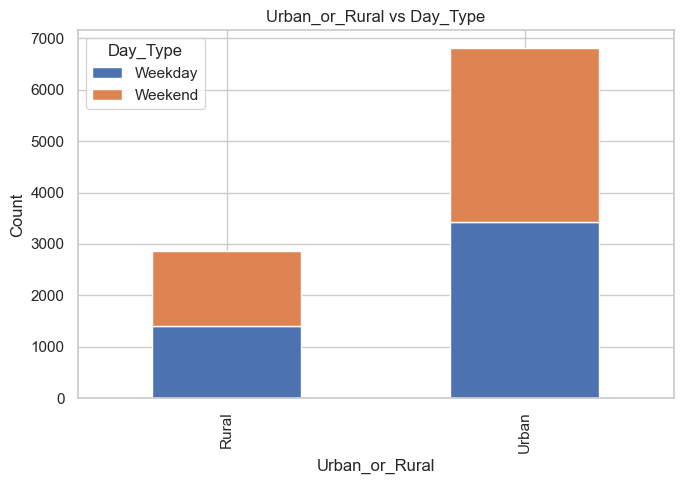

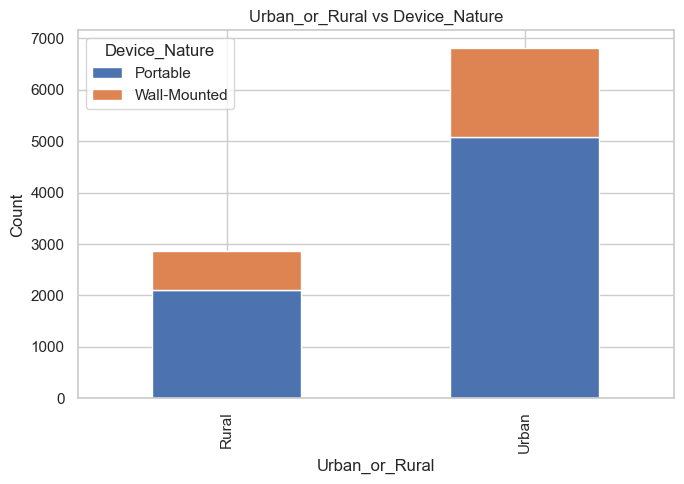

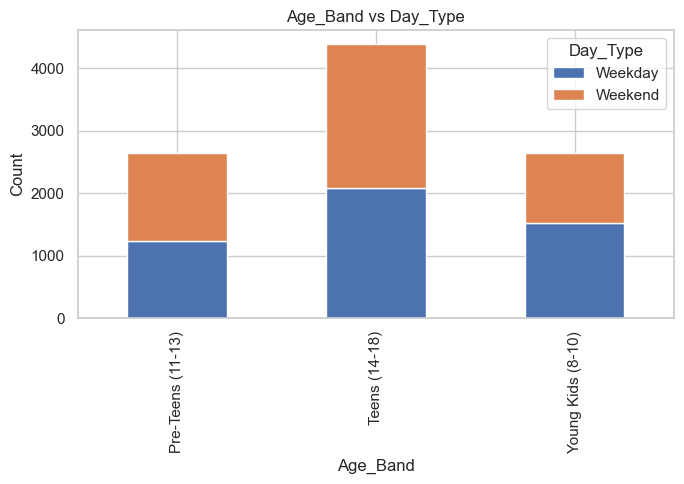

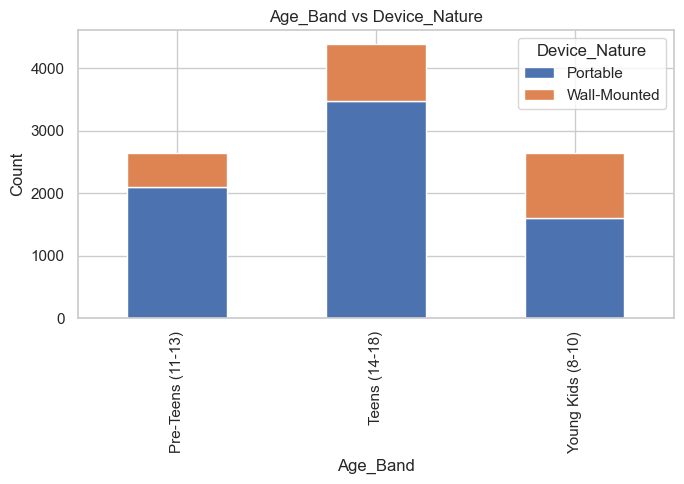

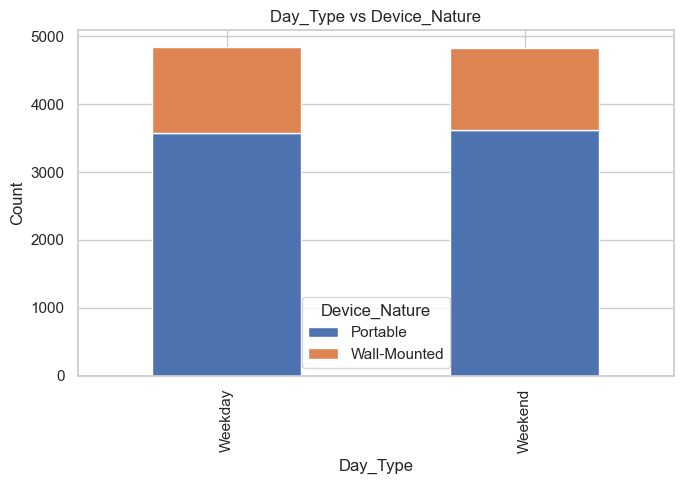

In [79]:
#  CATEGORICAL vs CATEGORICAL → COUNT BAR CHART

for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        cross_tab = pd.crosstab(df[categorical_cols[i]], df[categorical_cols[j]])
        
        cross_tab.plot(kind='bar', stacked=True, figsize=(7,5))
        plt.title(f"{categorical_cols[i]} vs {categorical_cols[j]}")
        plt.xlabel(categorical_cols[i])
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

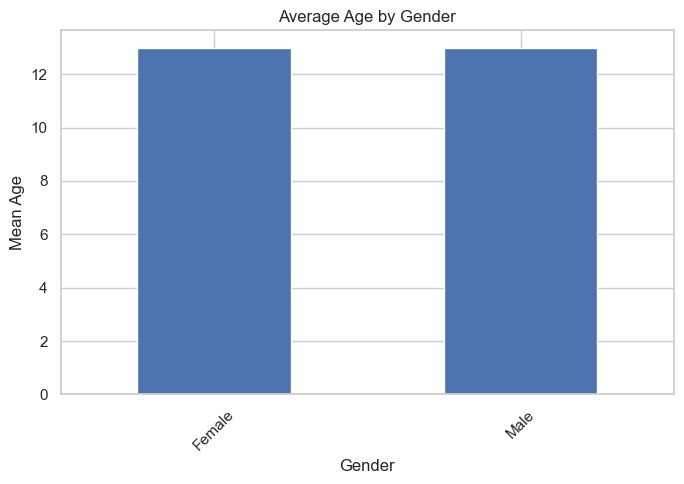

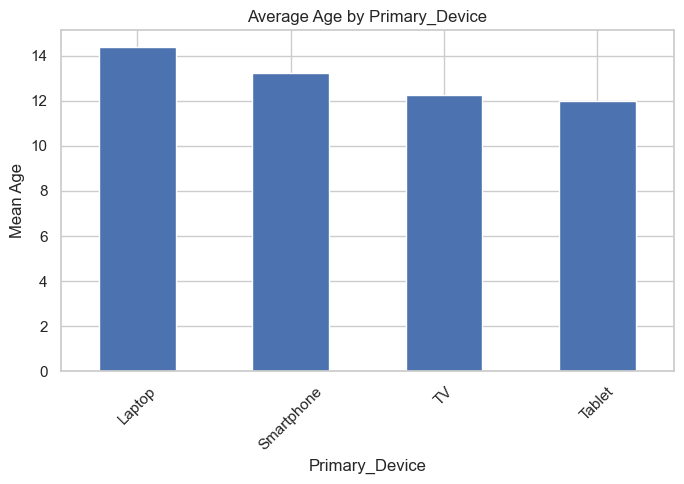

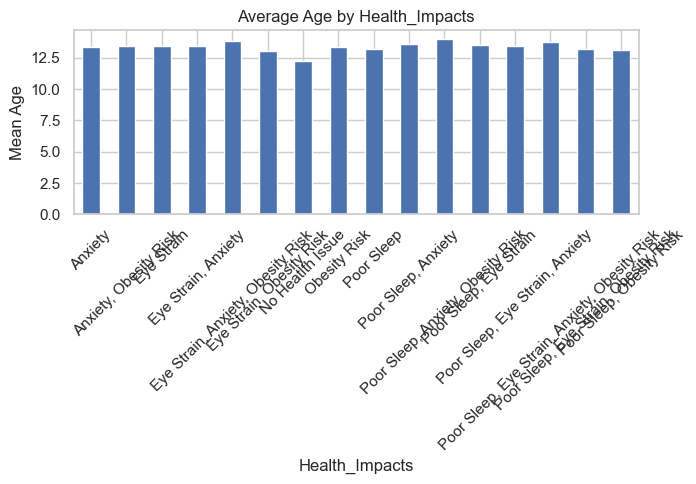

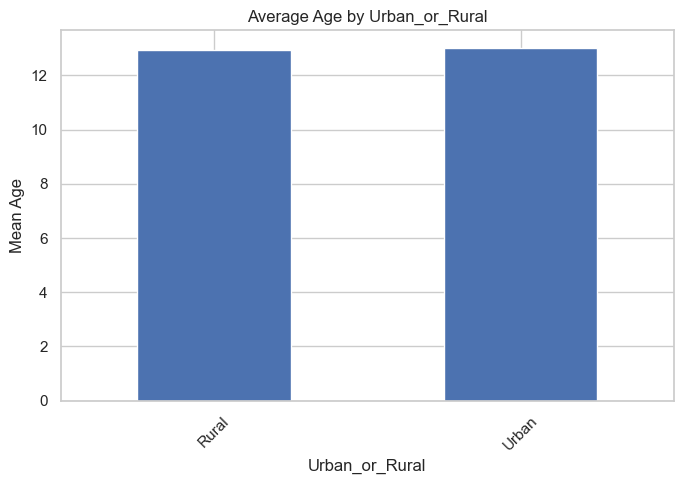

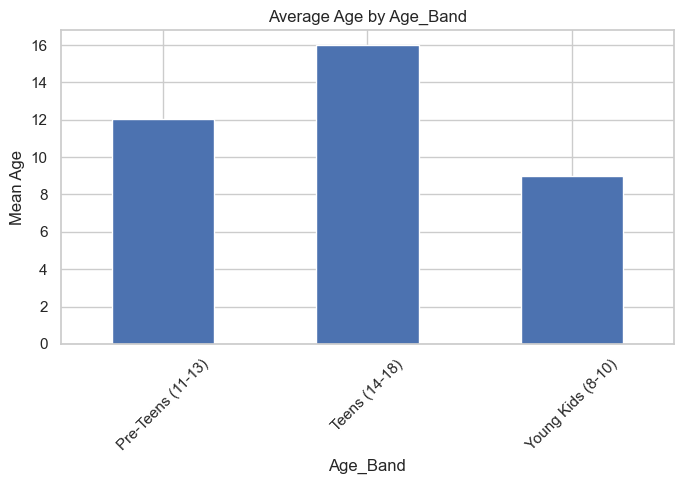

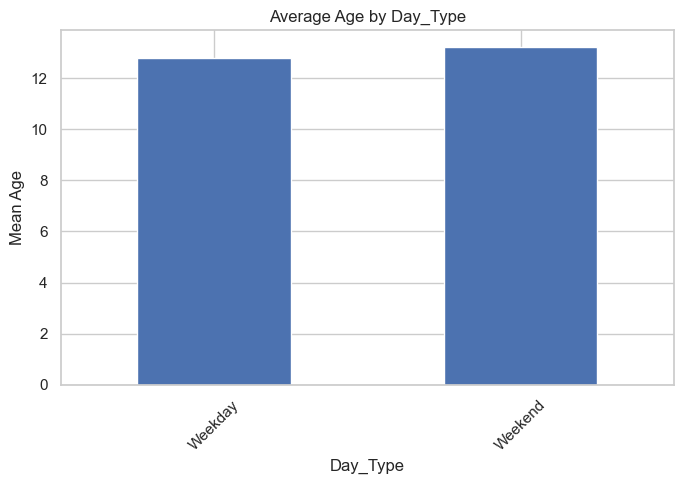

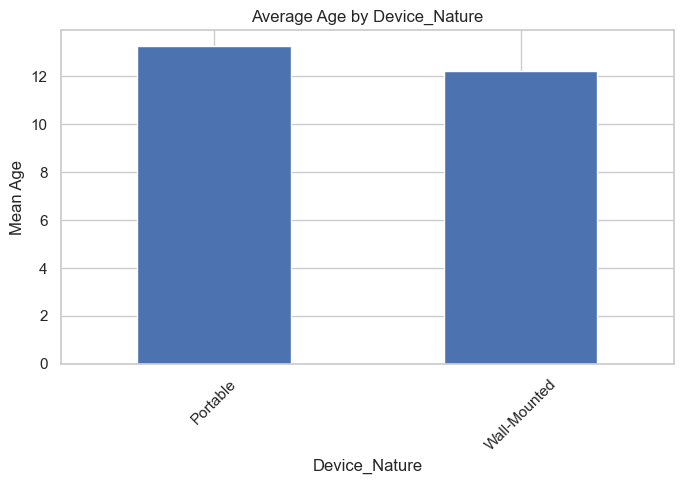

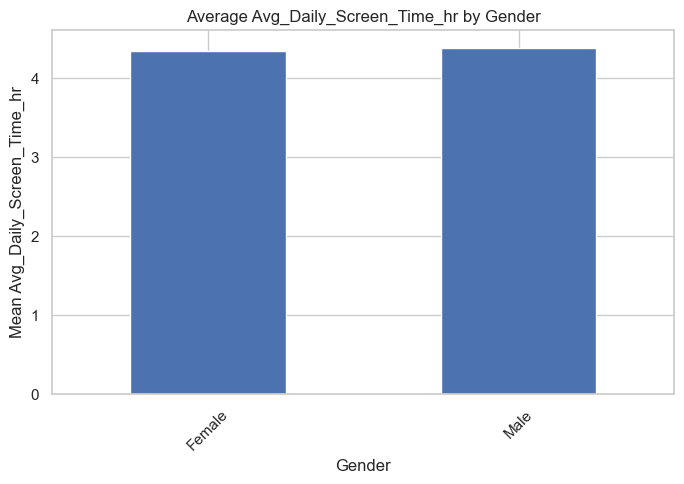

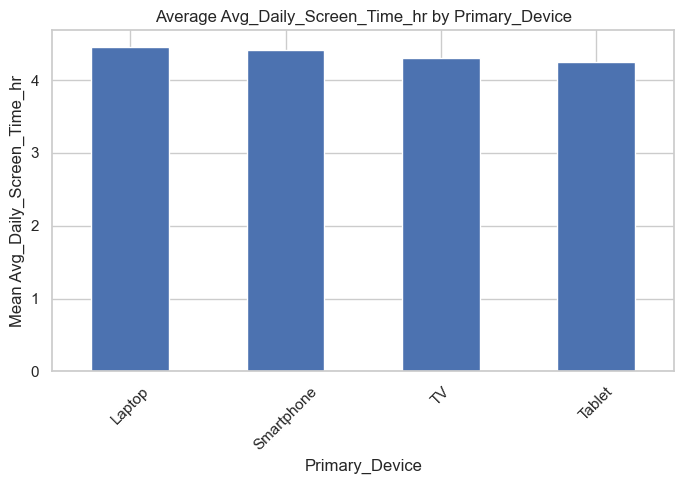

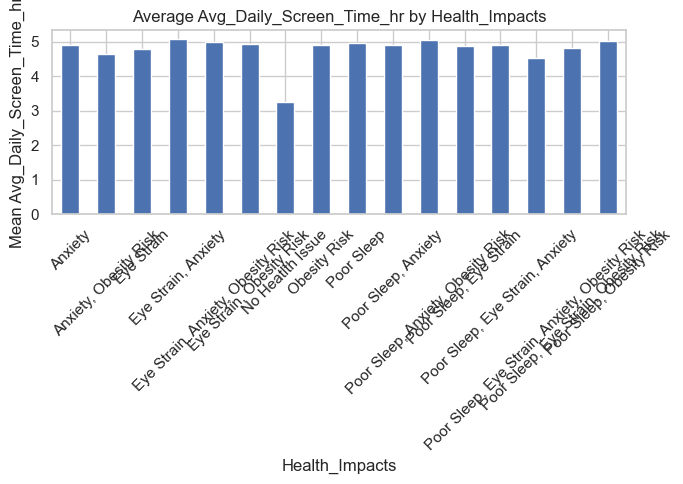

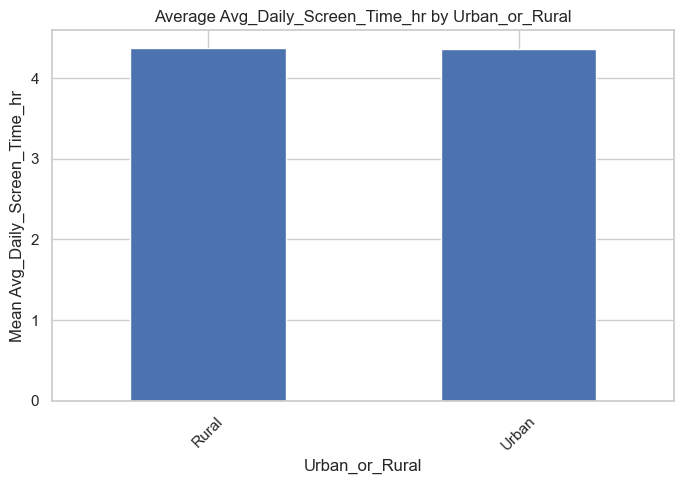

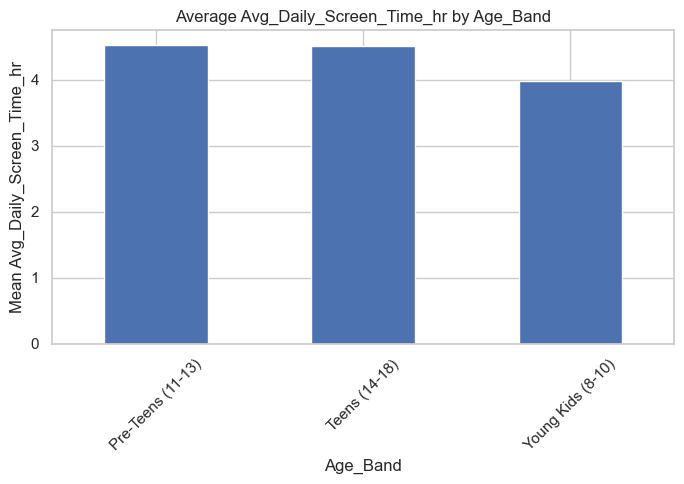

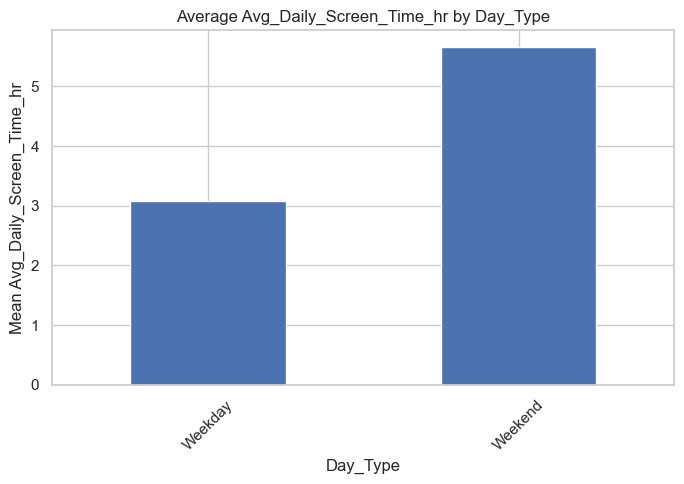

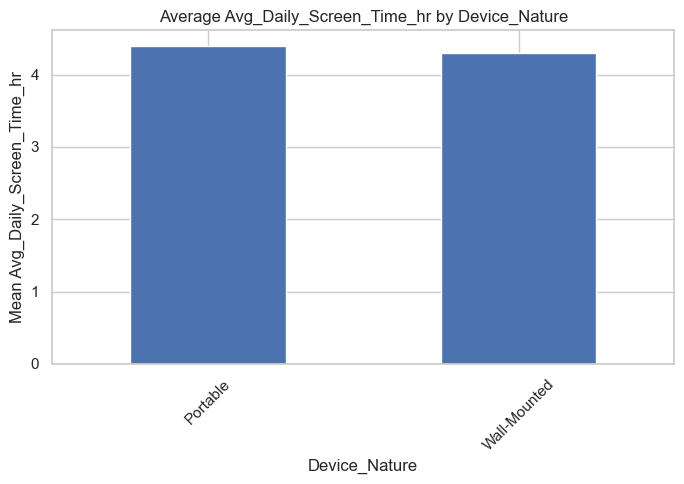

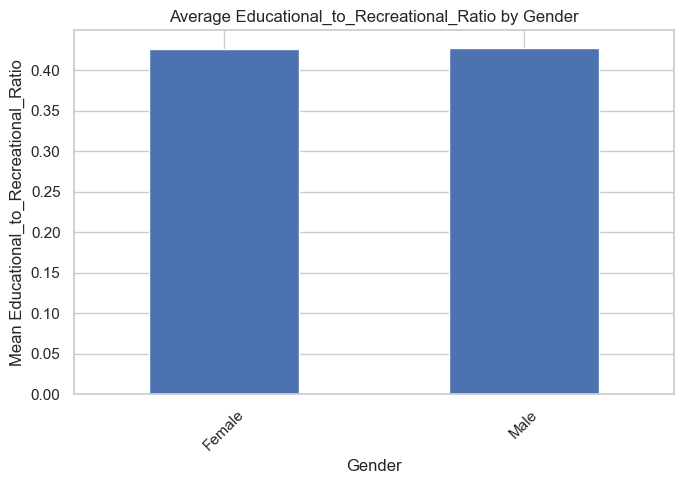

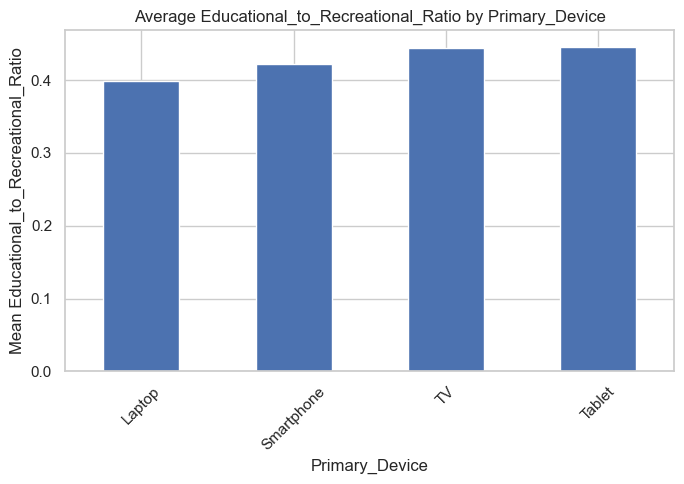

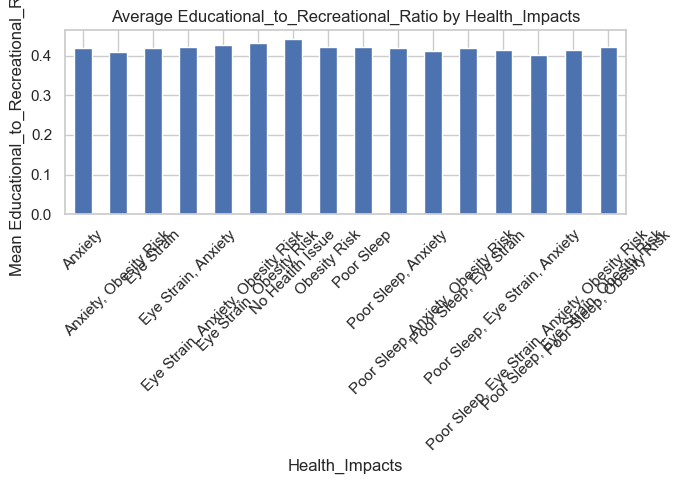

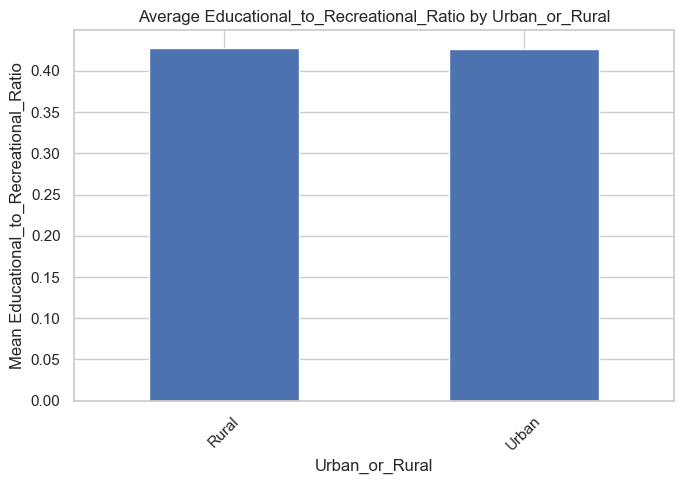

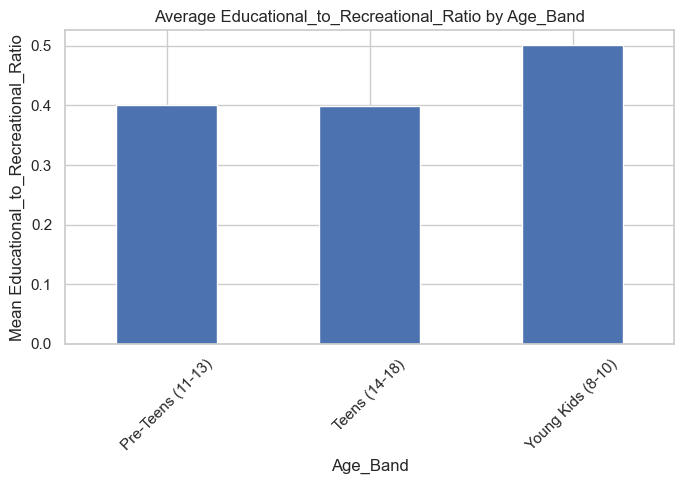

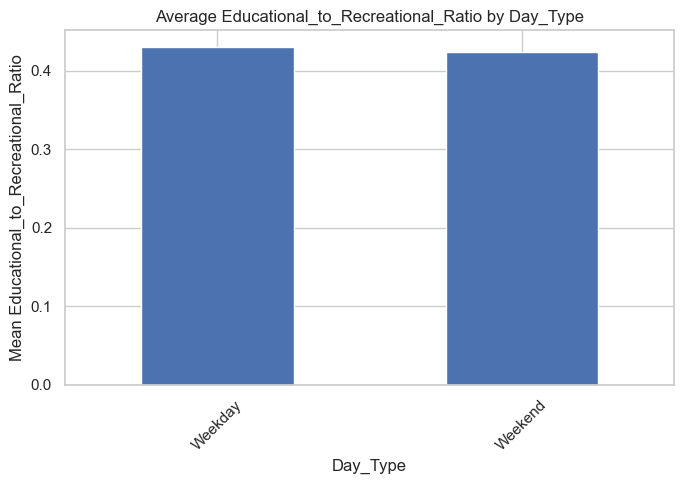

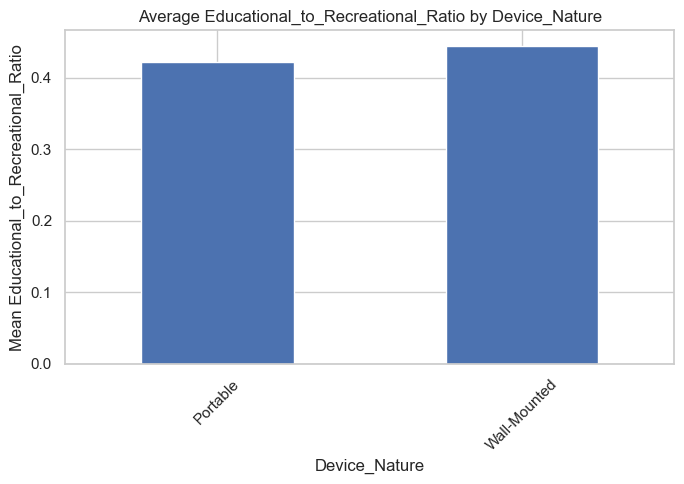

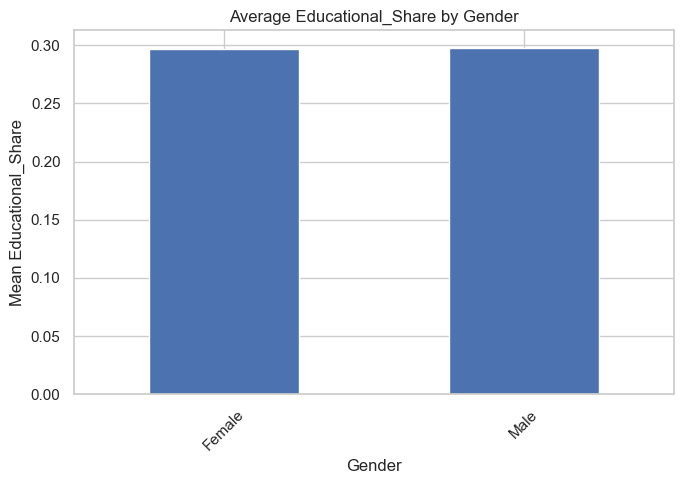

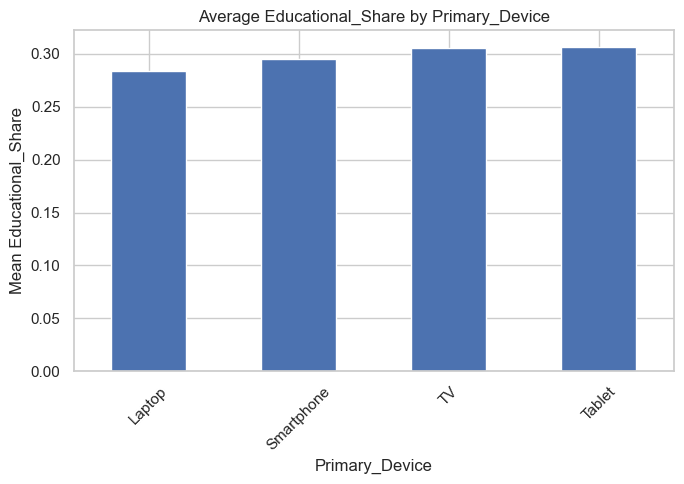

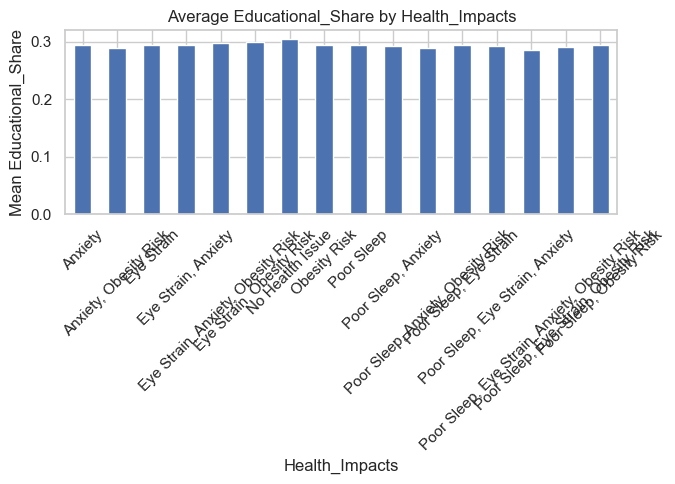

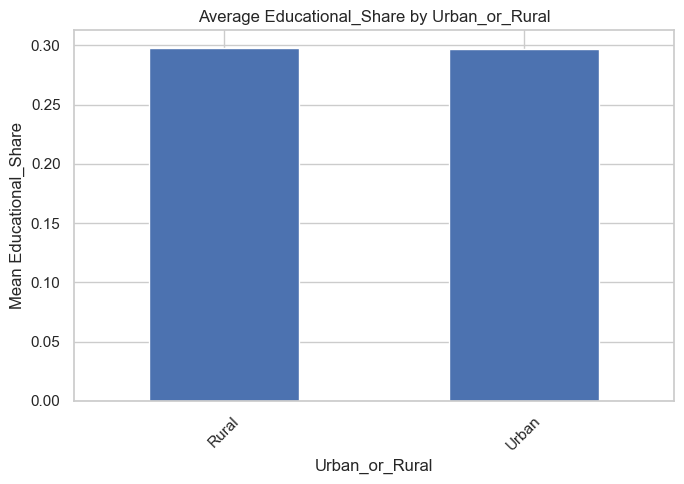

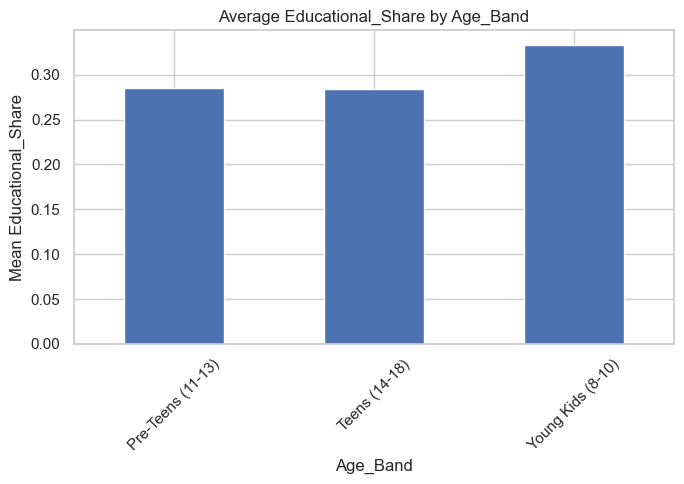

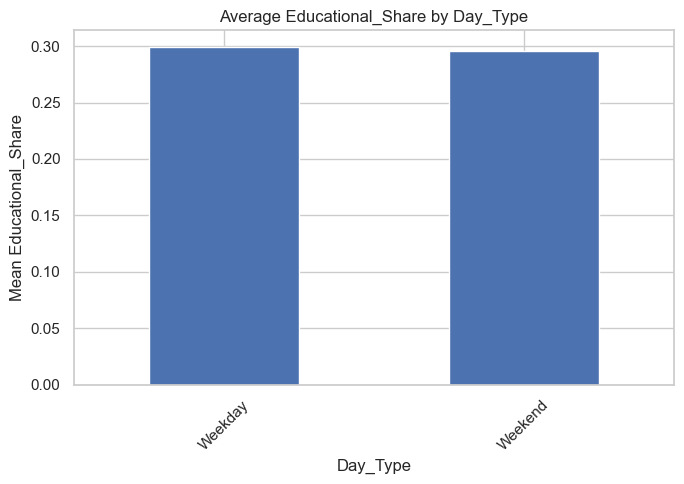

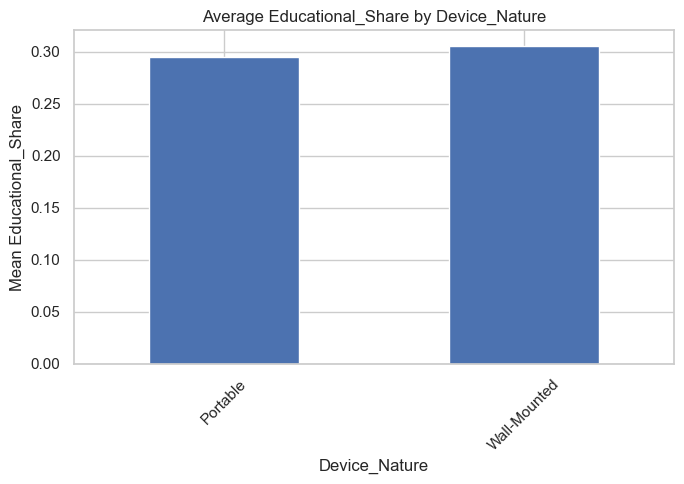

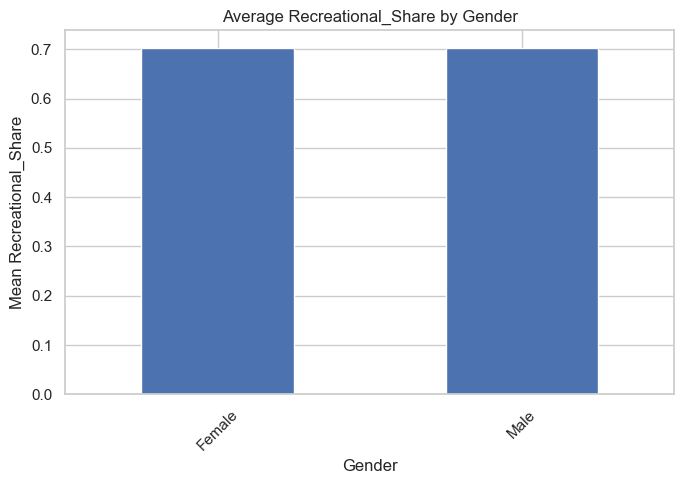

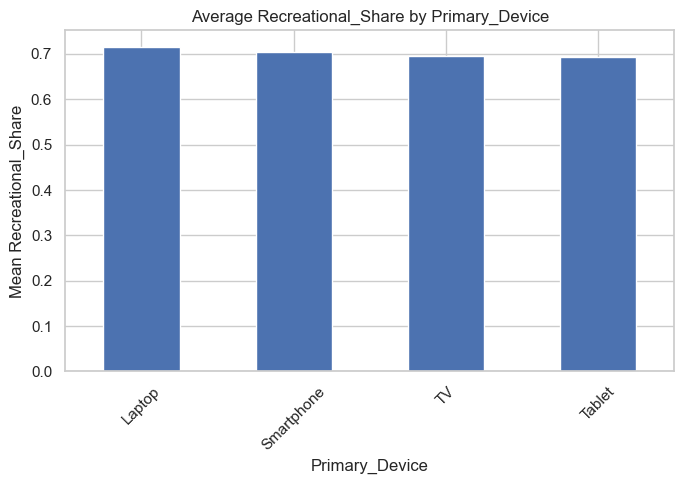

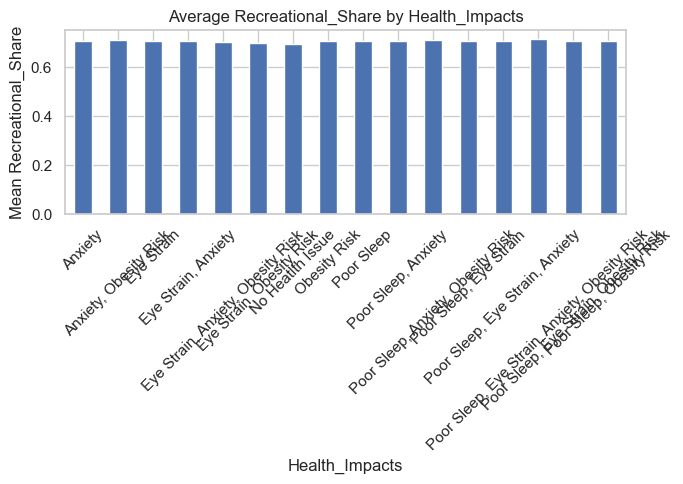

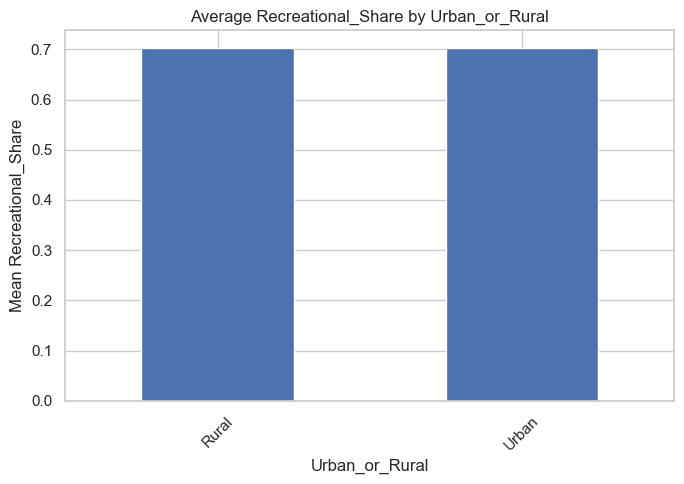

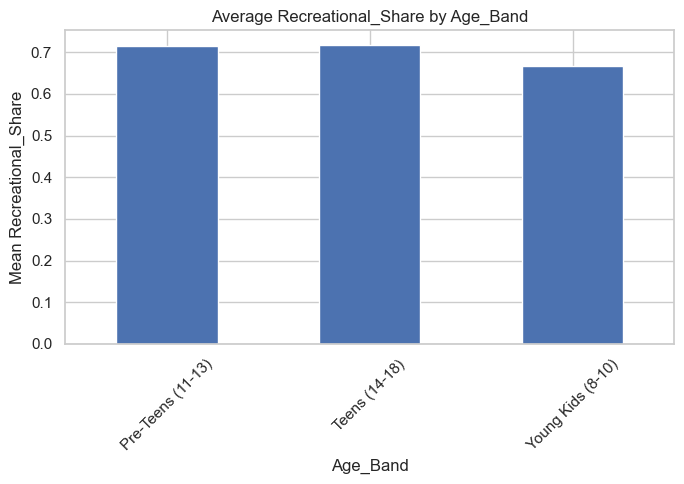

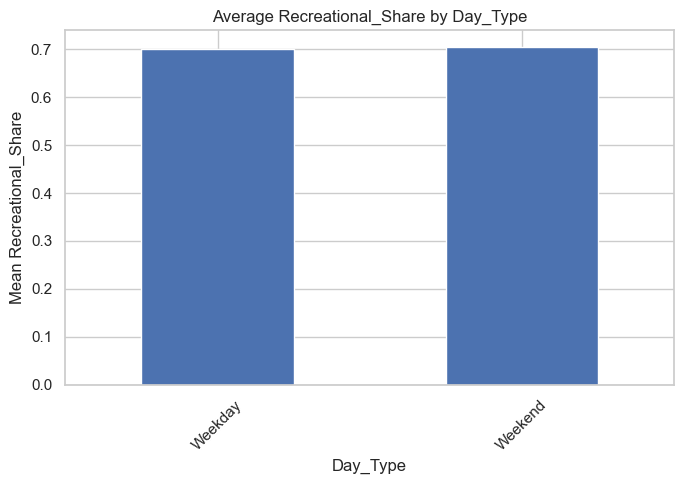

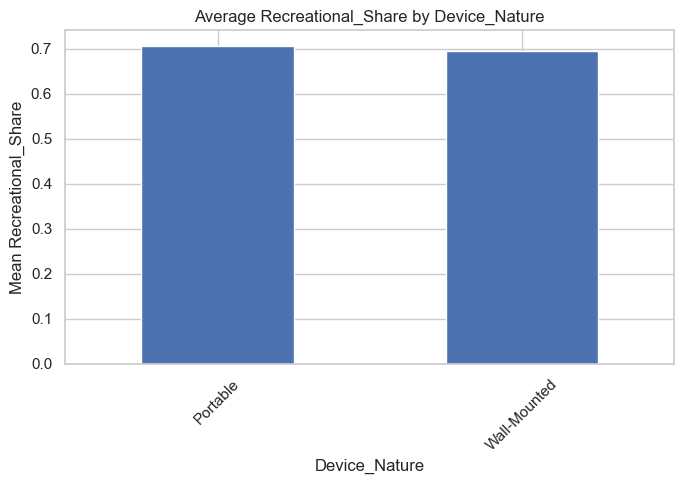

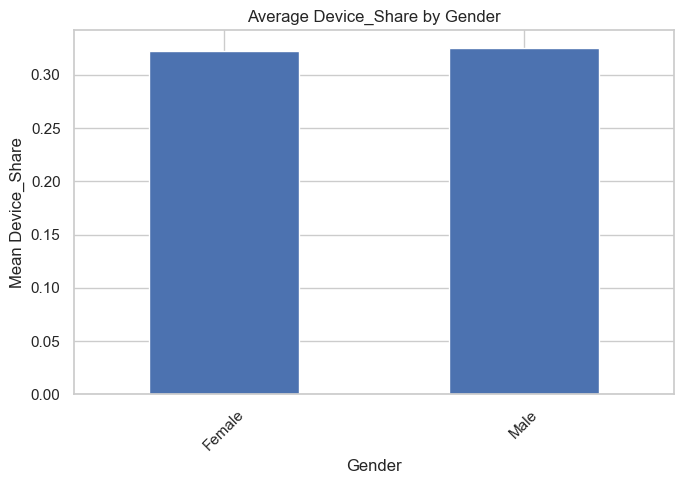

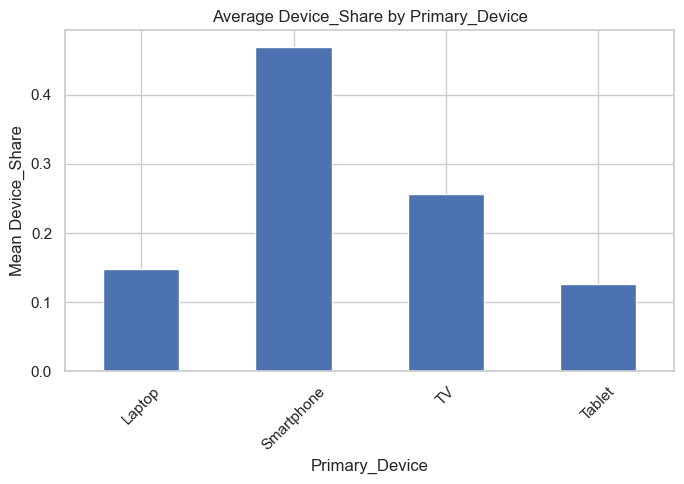

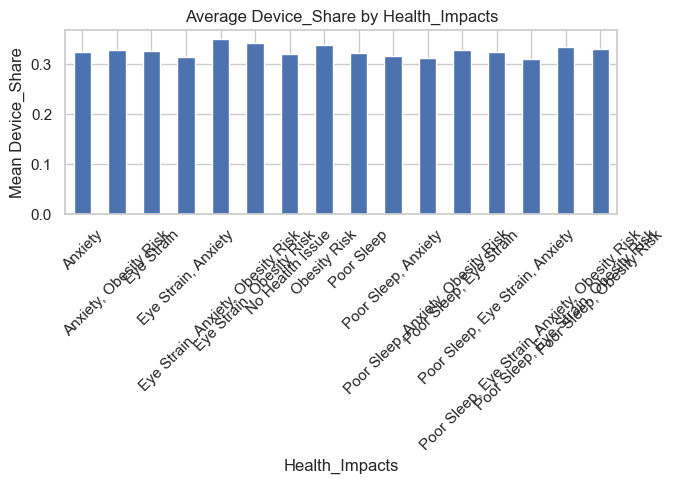

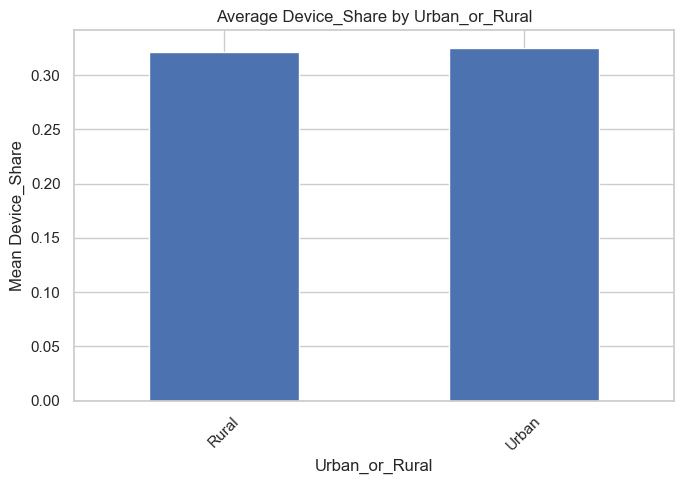

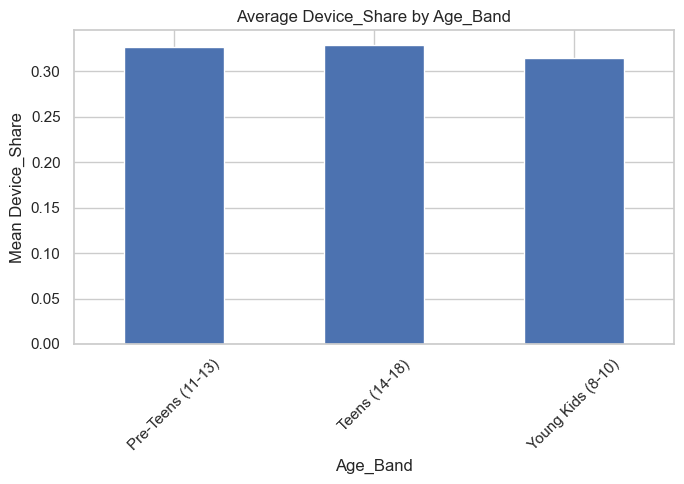

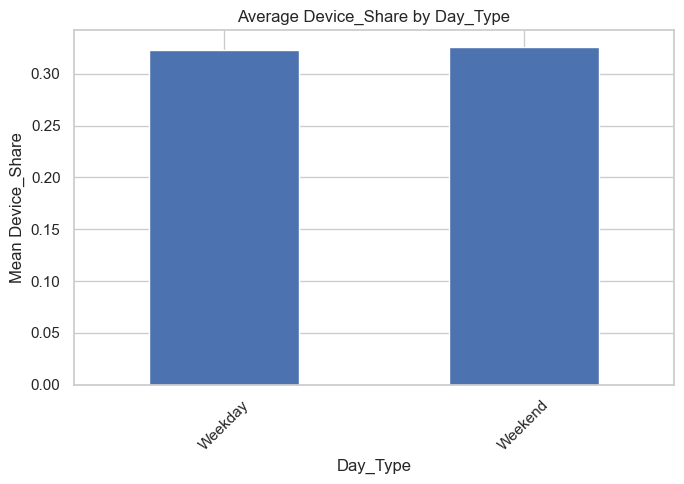

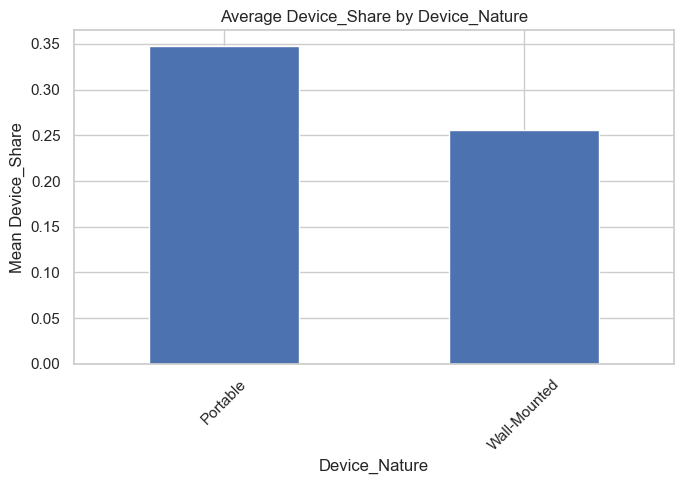

In [85]:
#Bar Plot for Numerical vs Categorica
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        
        # Compute mean of numerical column grouped by category
        grouped_data = df.groupby(cat_col)[num_col].mean().dropna()
        
        plt.figure(figsize=(7,5))
        grouped_data.plot(kind='bar')
        
        plt.title(f"Average {num_col} by {cat_col}")
        plt.xlabel(cat_col)
        plt.ylabel(f"Mean {num_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

<Figure size 600x400 with 0 Axes>

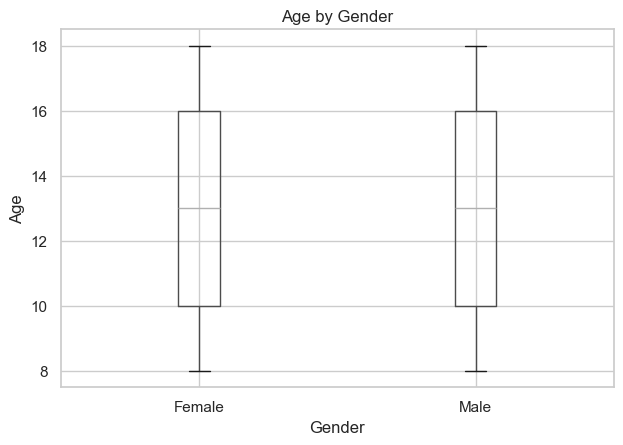

<Figure size 600x400 with 0 Axes>

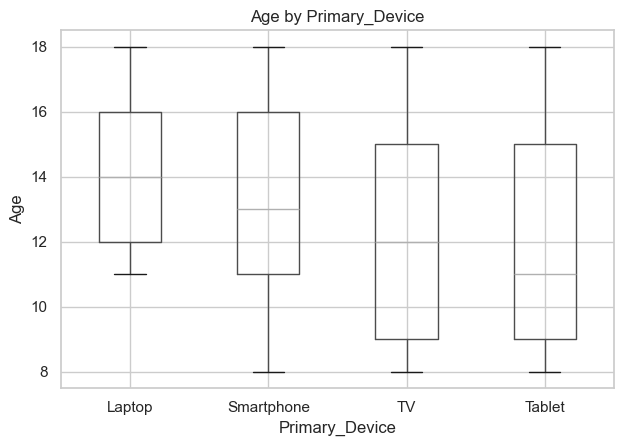

<Figure size 600x400 with 0 Axes>

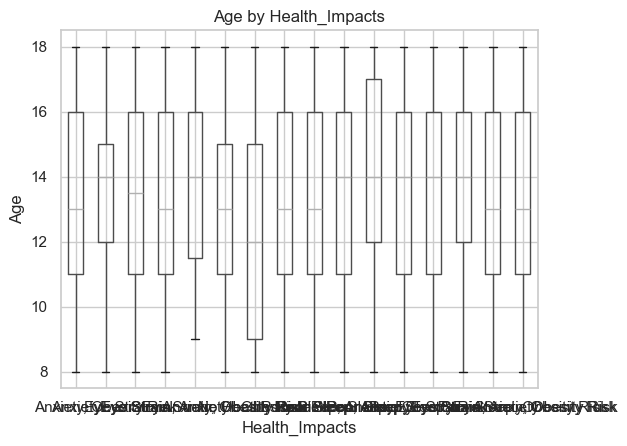

<Figure size 600x400 with 0 Axes>

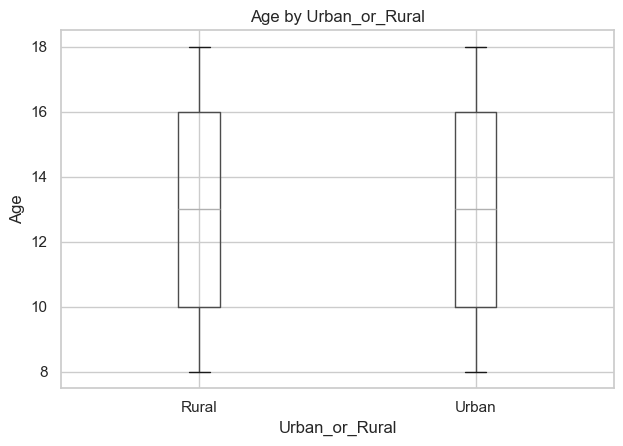

<Figure size 600x400 with 0 Axes>

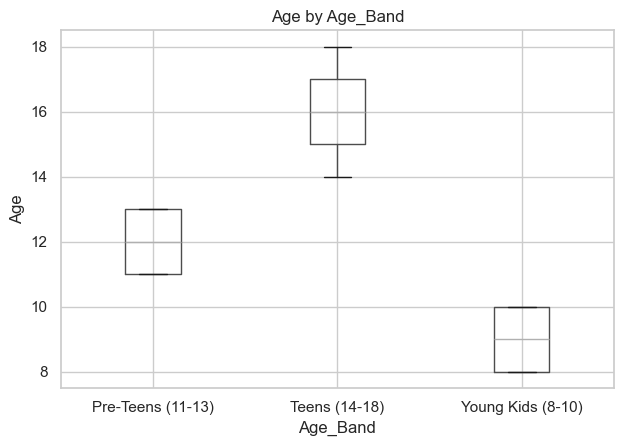

<Figure size 600x400 with 0 Axes>

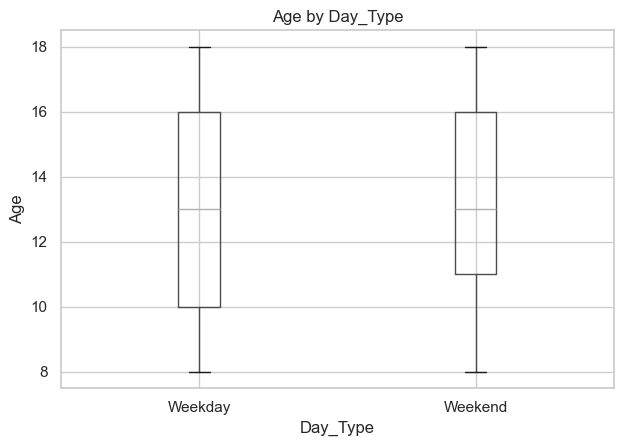

<Figure size 600x400 with 0 Axes>

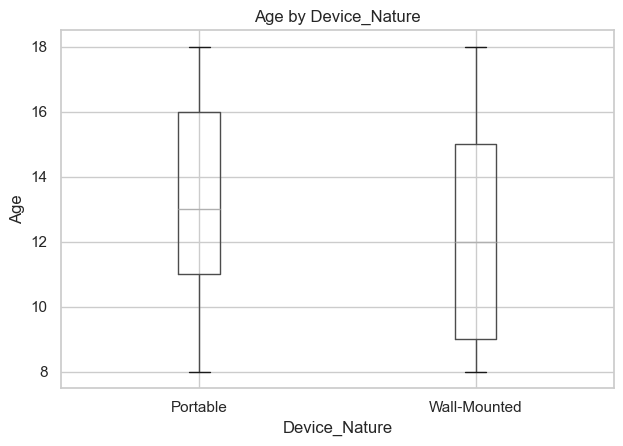

<Figure size 600x400 with 0 Axes>

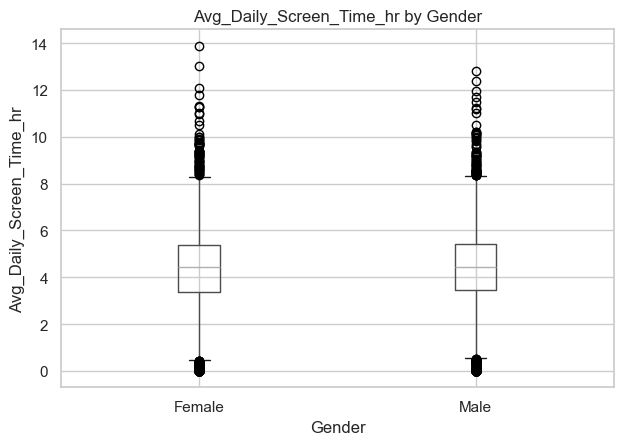

<Figure size 600x400 with 0 Axes>

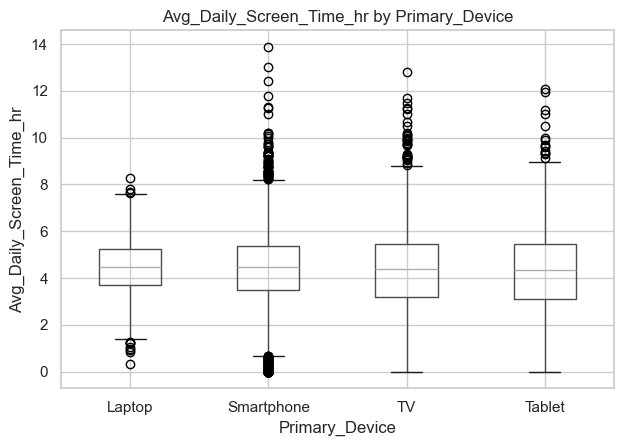

<Figure size 600x400 with 0 Axes>

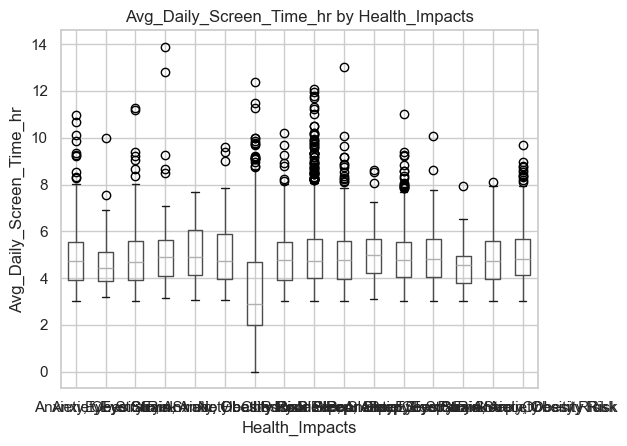

<Figure size 600x400 with 0 Axes>

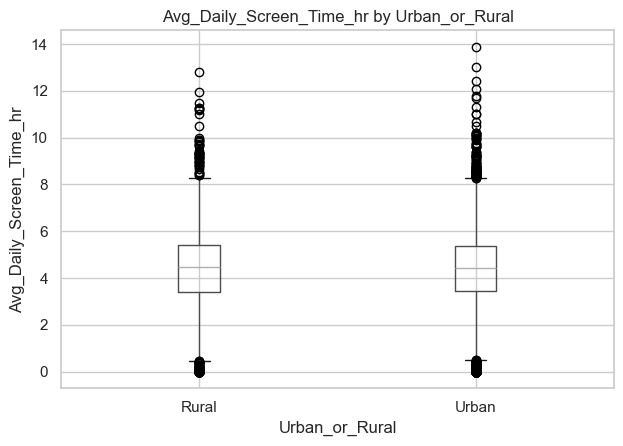

<Figure size 600x400 with 0 Axes>

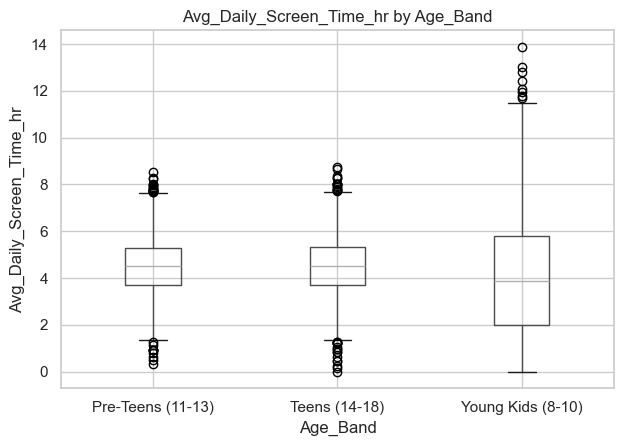

<Figure size 600x400 with 0 Axes>

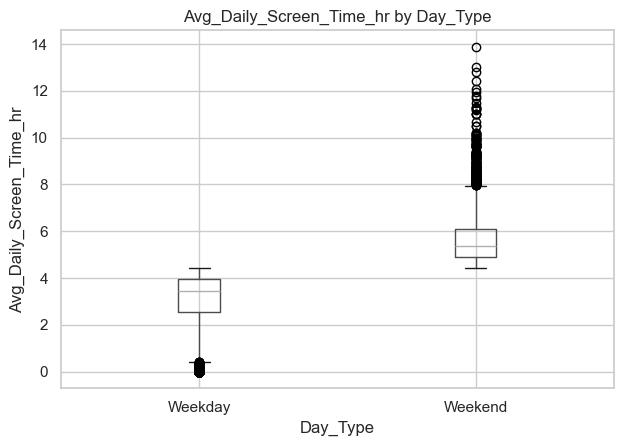

<Figure size 600x400 with 0 Axes>

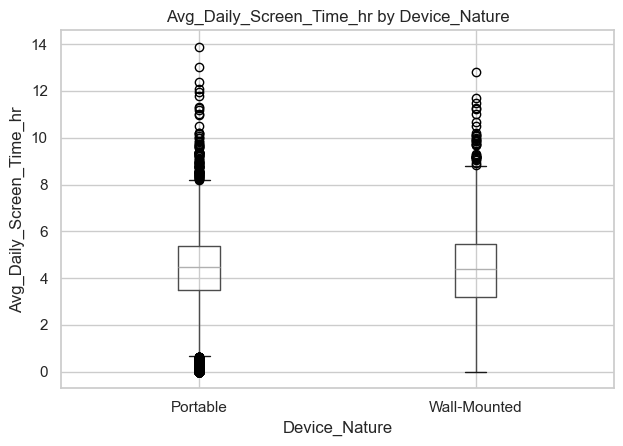

<Figure size 600x400 with 0 Axes>

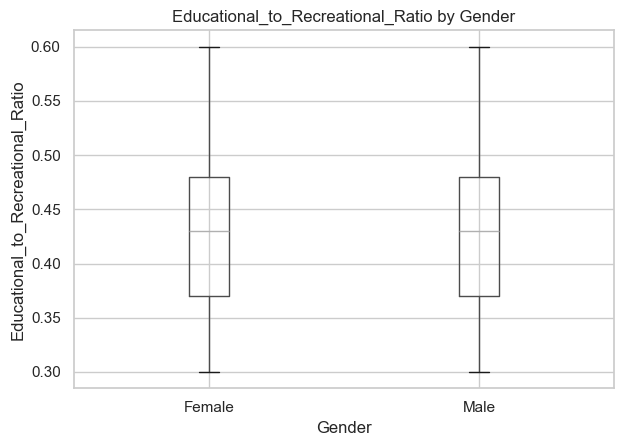

<Figure size 600x400 with 0 Axes>

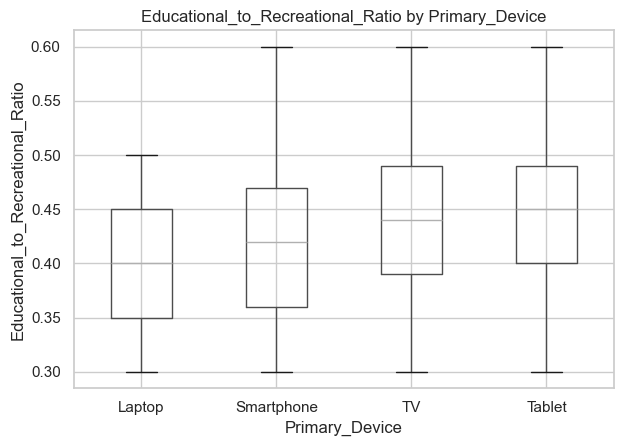

<Figure size 600x400 with 0 Axes>

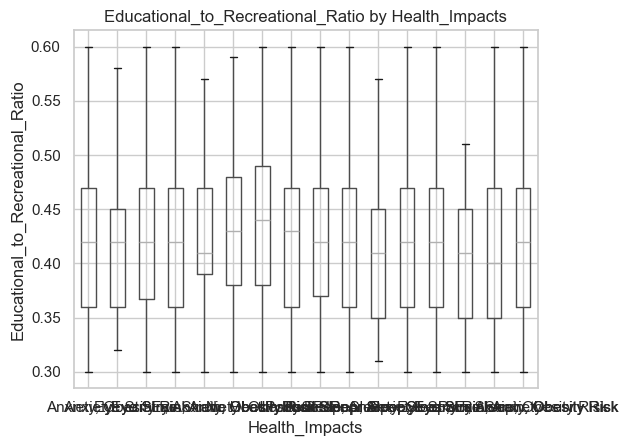

<Figure size 600x400 with 0 Axes>

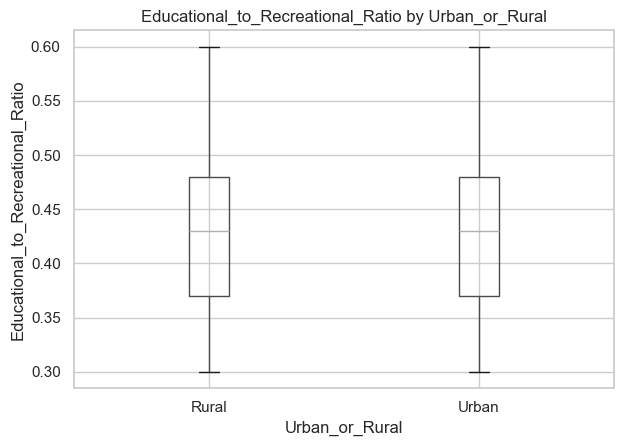

<Figure size 600x400 with 0 Axes>

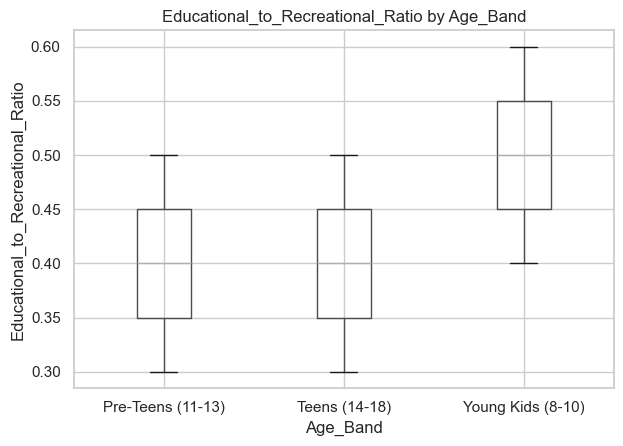

<Figure size 600x400 with 0 Axes>

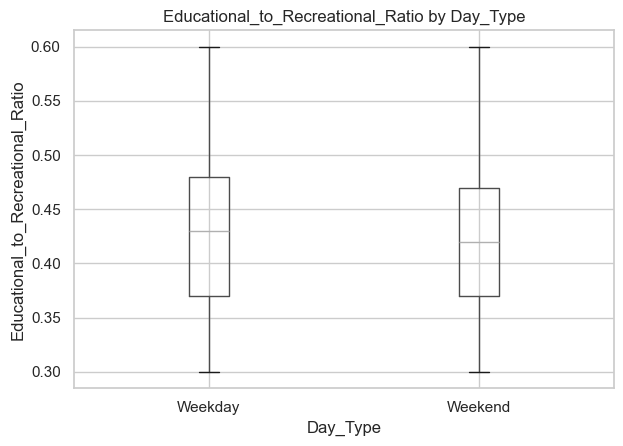

<Figure size 600x400 with 0 Axes>

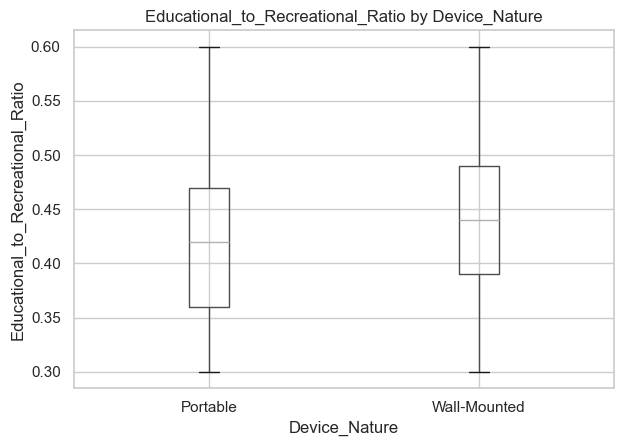

<Figure size 600x400 with 0 Axes>

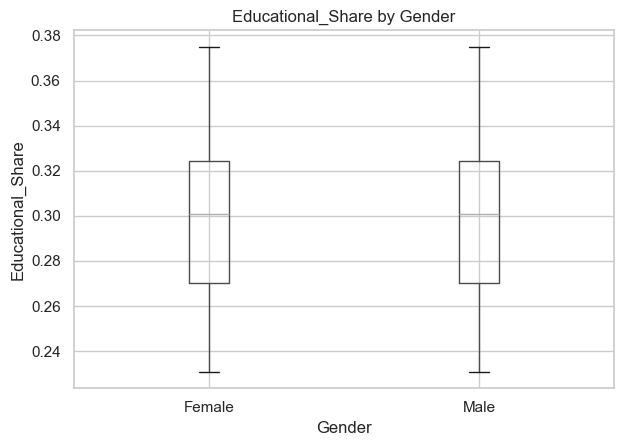

<Figure size 600x400 with 0 Axes>

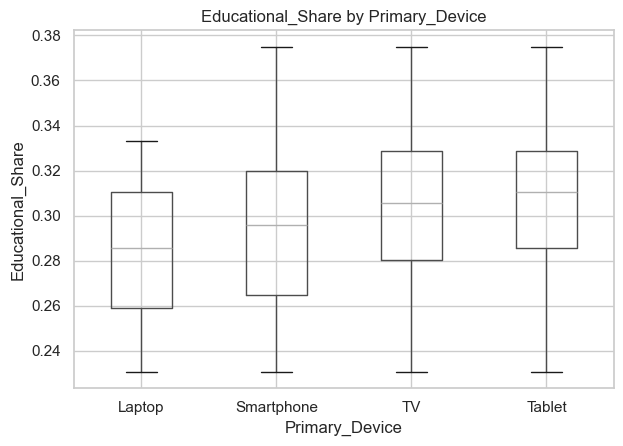

<Figure size 600x400 with 0 Axes>

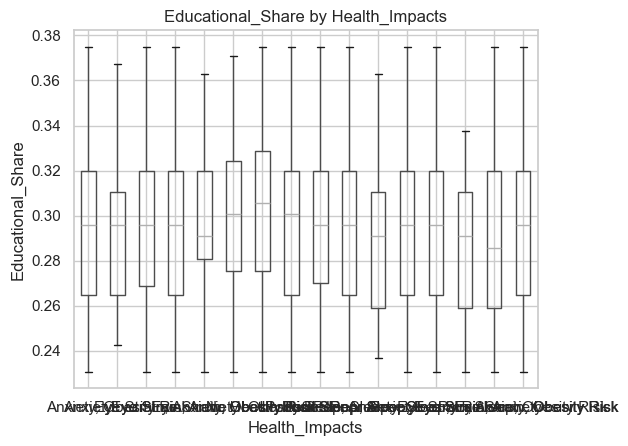

<Figure size 600x400 with 0 Axes>

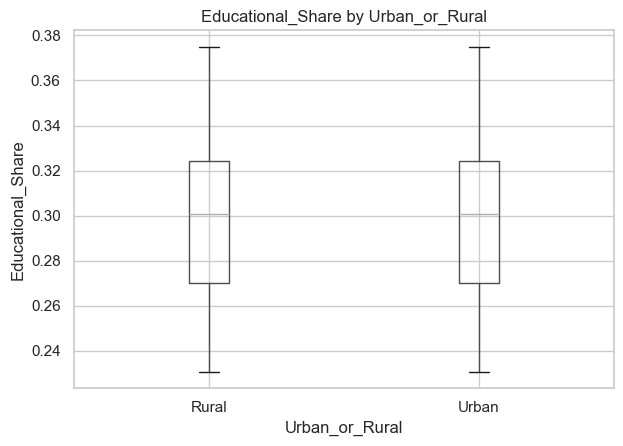

<Figure size 600x400 with 0 Axes>

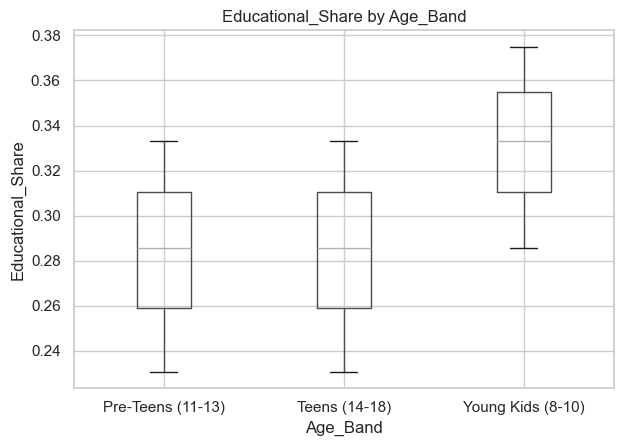

<Figure size 600x400 with 0 Axes>

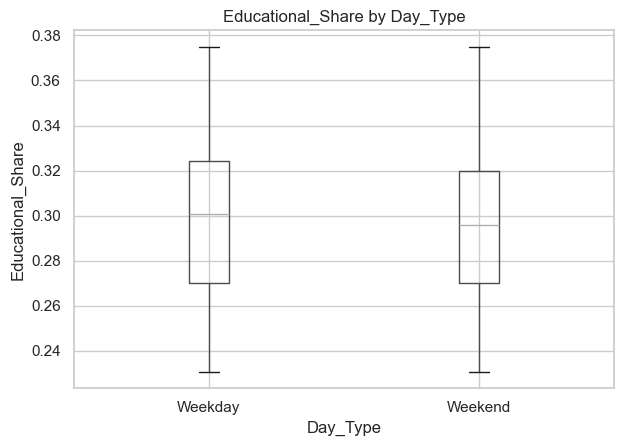

<Figure size 600x400 with 0 Axes>

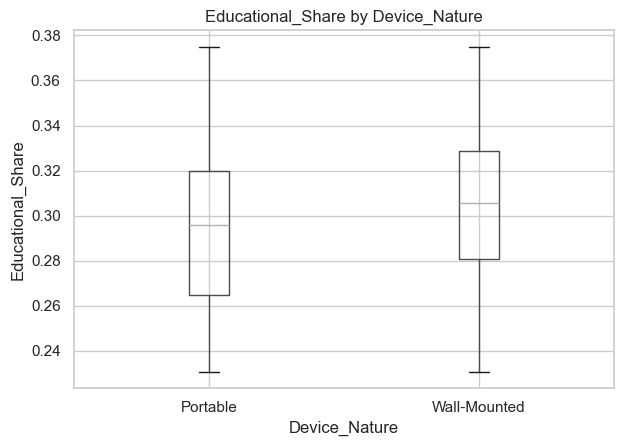

<Figure size 600x400 with 0 Axes>

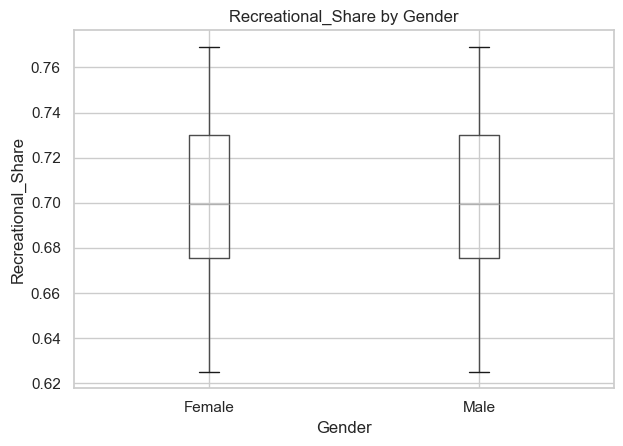

<Figure size 600x400 with 0 Axes>

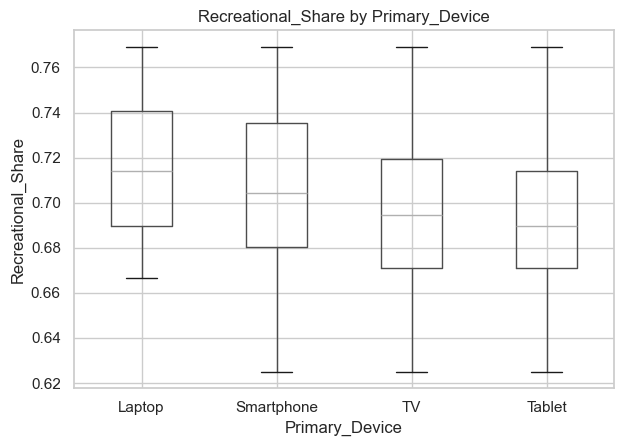

<Figure size 600x400 with 0 Axes>

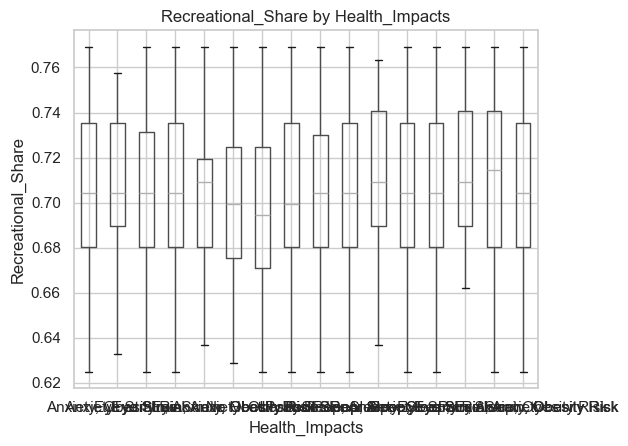

<Figure size 600x400 with 0 Axes>

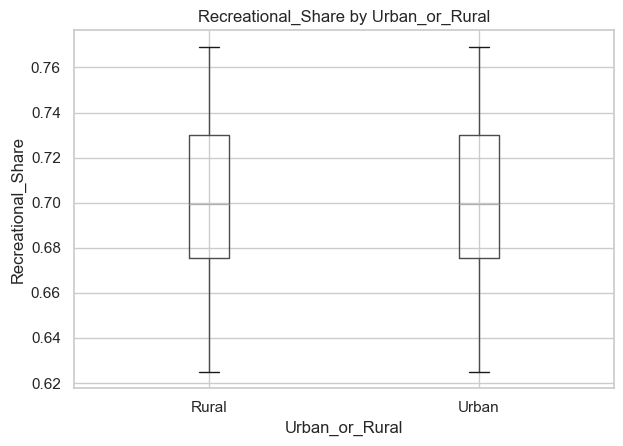

<Figure size 600x400 with 0 Axes>

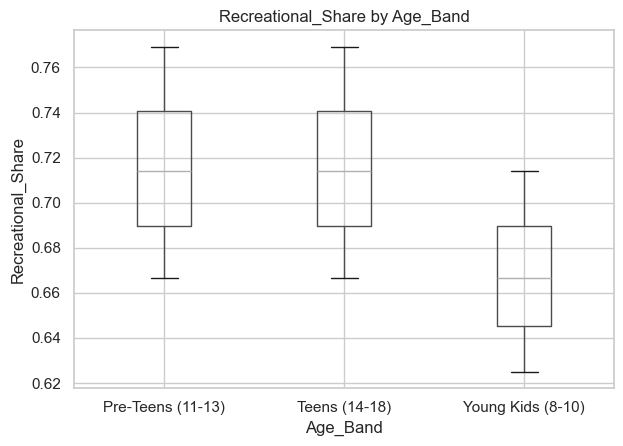

<Figure size 600x400 with 0 Axes>

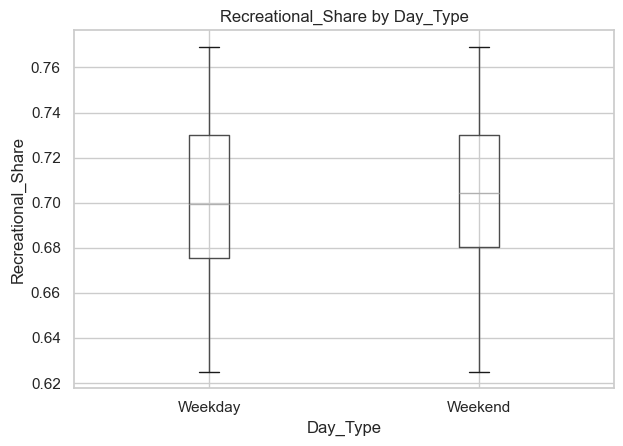

<Figure size 600x400 with 0 Axes>

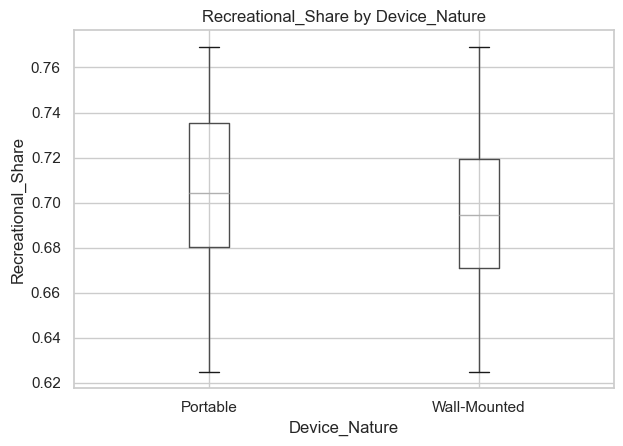

<Figure size 600x400 with 0 Axes>

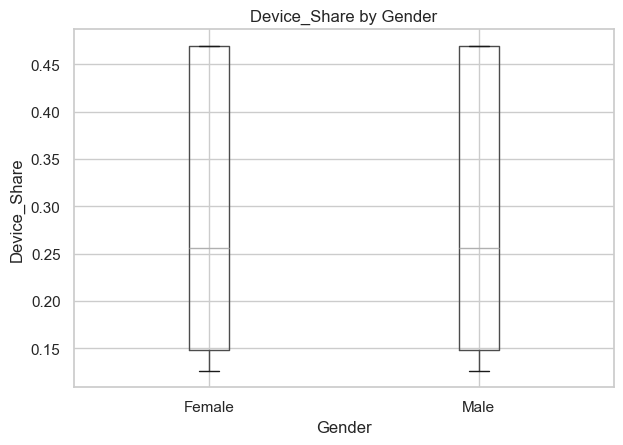

<Figure size 600x400 with 0 Axes>

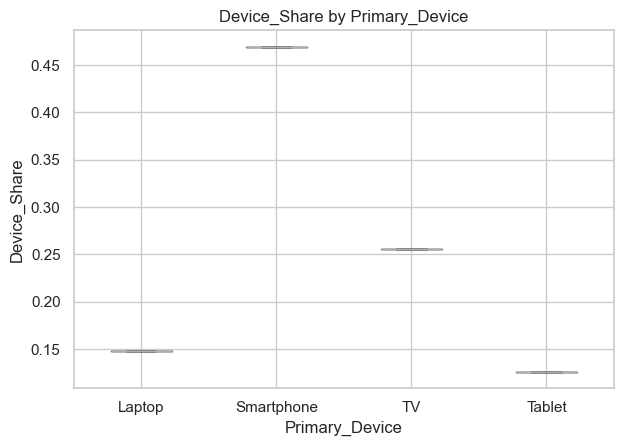

<Figure size 600x400 with 0 Axes>

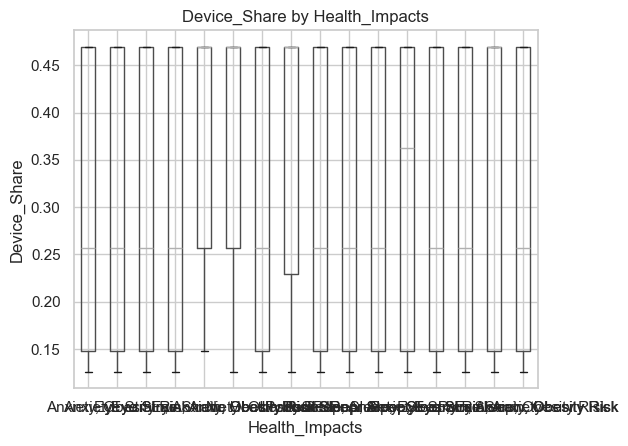

<Figure size 600x400 with 0 Axes>

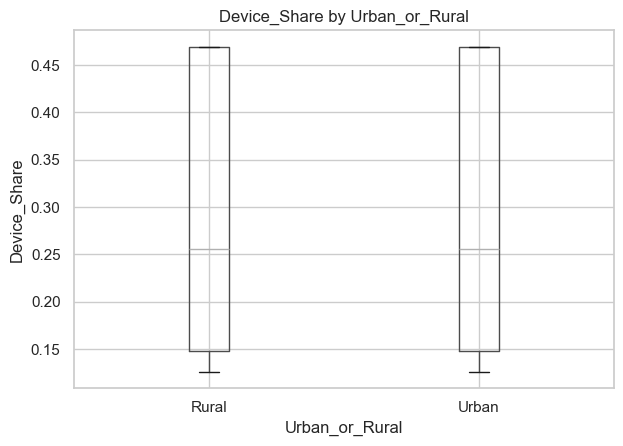

<Figure size 600x400 with 0 Axes>

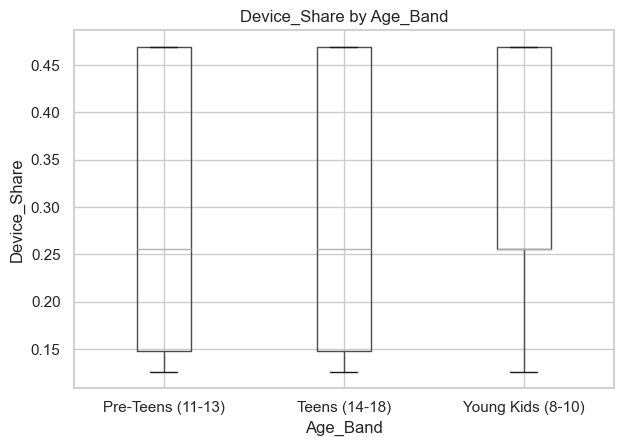

<Figure size 600x400 with 0 Axes>

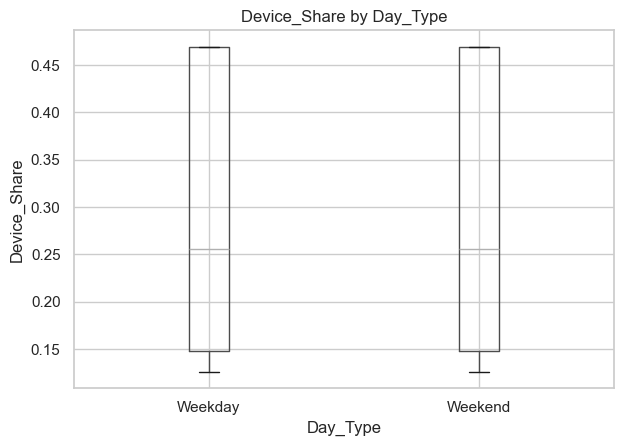

<Figure size 600x400 with 0 Axes>

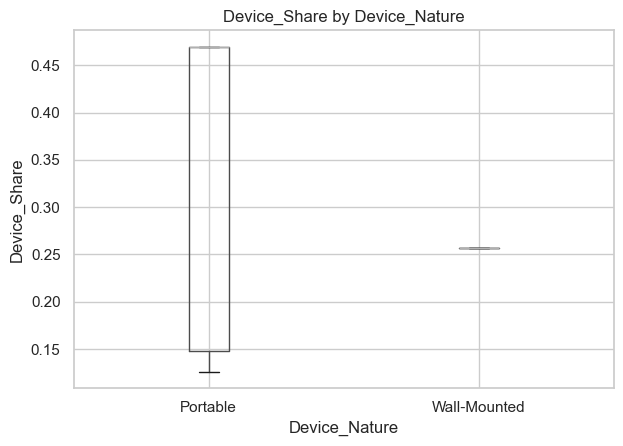

In [84]:
#NUMERICAL vs CATEGORICAL → BOXPLOTS
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        plt.figure(figsize=(6,4))
        df.boxplot(column=num_col, by=cat_col)
        plt.title(f"{num_col} by {cat_col}")
        plt.suptitle("")
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.tight_layout()
        plt.show()



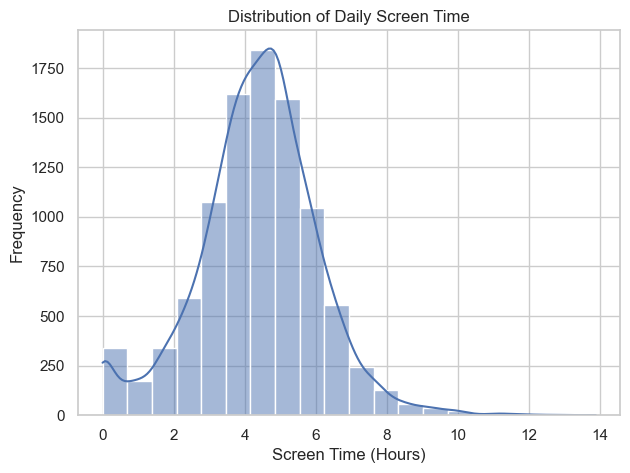

In [88]:

plt.figure(figsize=(7,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True)

plt.title("Distribution of Daily Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()

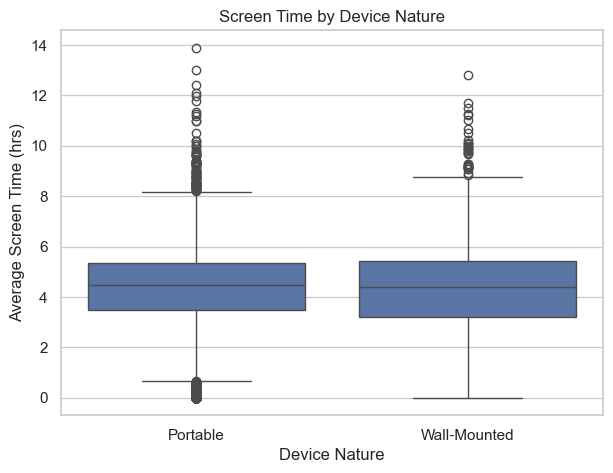

In [89]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Device_Nature",
    y="Avg_Daily_Screen_Time_hr"
)

plt.title("Screen Time by Device Nature")
plt.xlabel("Device Nature")
plt.ylabel("Average Screen Time (hrs)")

plt.show()

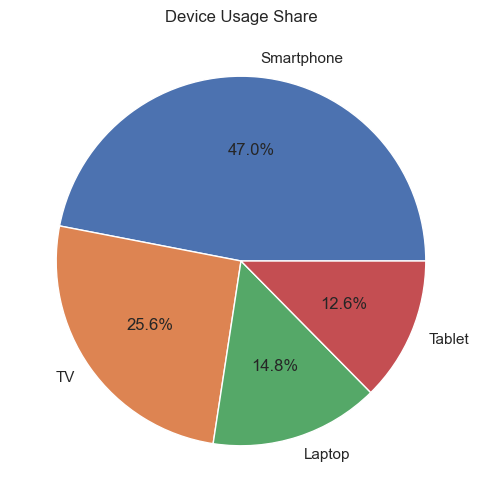

In [99]:
device_counts = df['Primary_Device'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%')

plt.title("Device Usage Share")
plt.show()

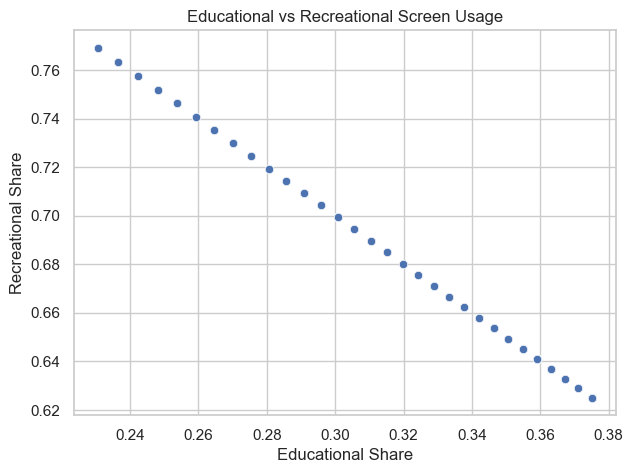

In [90]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Educational_Share",
    y="Recreational_Share"
)

plt.title("Educational vs Recreational Screen Usage")
plt.xlabel("Educational Share")
plt.ylabel("Recreational Share")

plt.show()

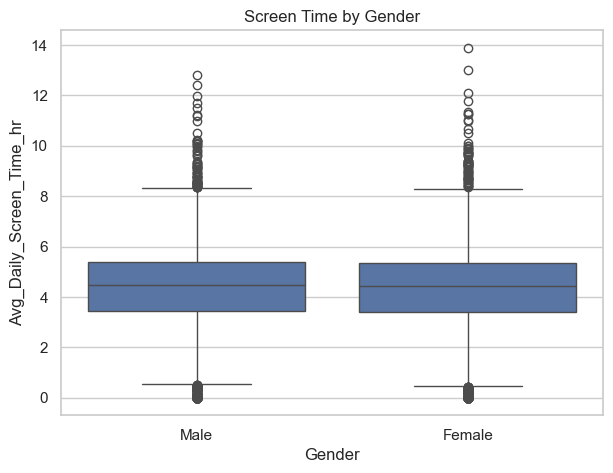

In [97]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time by Gender")
plt.show()

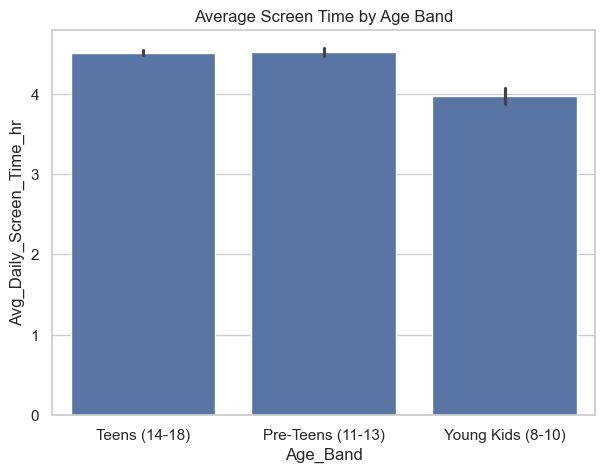

In [96]:
plt.figure(figsize=(7,5))
sns.barplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Average Screen Time by Age Band")
plt.show()

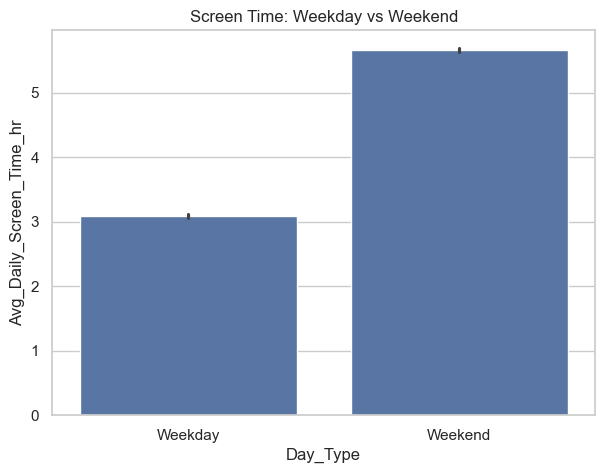

In [95]:
plt.figure(figsize=(7,5))
sns.barplot(x='Day_Type', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time: Weekday vs Weekend")
plt.show()

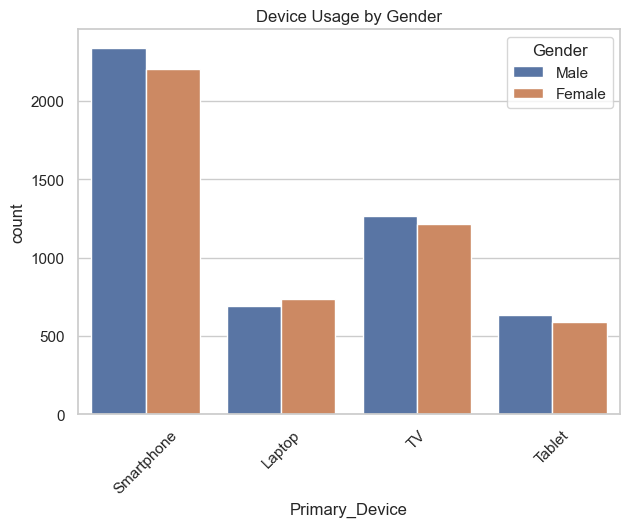

In [98]:
plt.figure(figsize=(7,5))
sns.countplot(x='Primary_Device', hue='Gender', data=df)

plt.title("Device Usage by Gender")
plt.xticks(rotation=45)
plt.show()

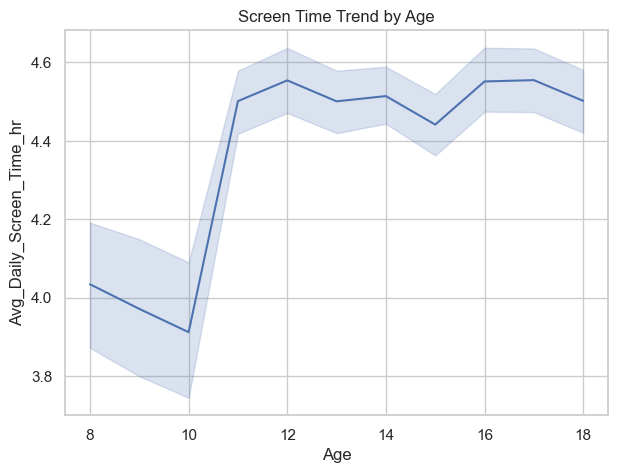

In [94]:
df_sorted = df.sort_values('Age')

plt.figure(figsize=(7,5))
sns.lineplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df_sorted)

plt.title("Screen Time Trend by Age")
plt.show()

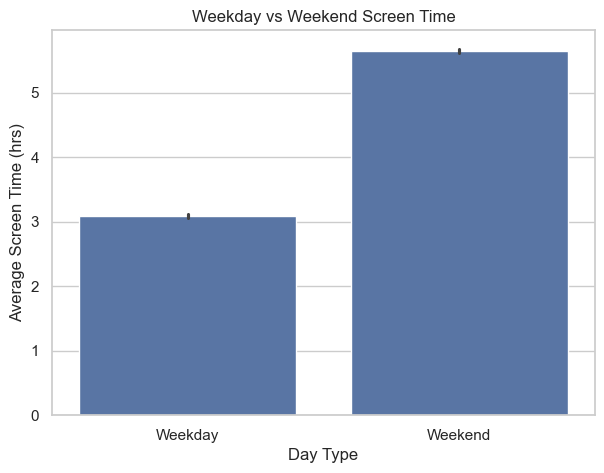

In [91]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Day_Type",
    y="Avg_Daily_Screen_Time_hr"
)

plt.title("Weekday vs Weekend Screen Time")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (hrs)")

plt.show()

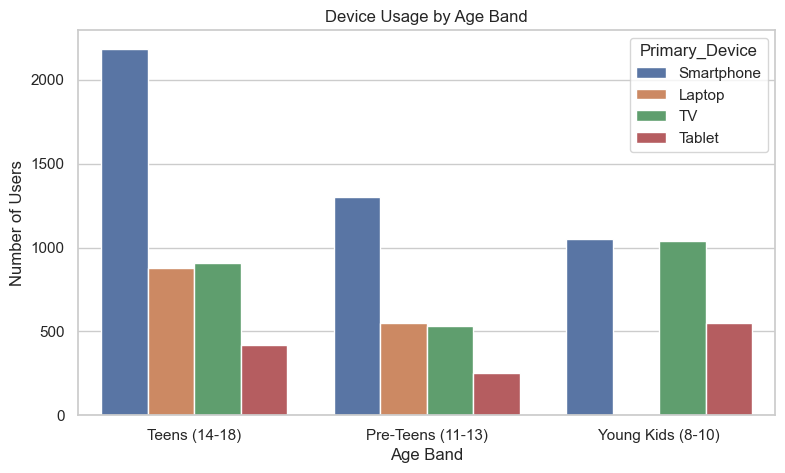

In [92]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Age_Band",
    hue="Primary_Device"
)

plt.title("Device Usage by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")

plt.show()

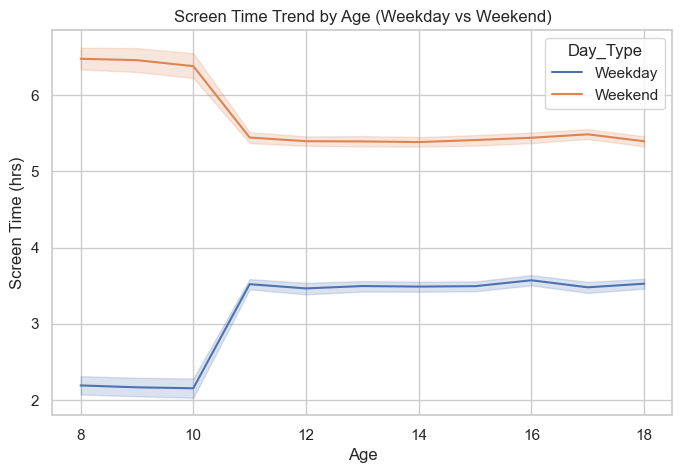

In [93]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x="Age",
    y="Avg_Daily_Screen_Time_hr",
    hue="Day_Type"
)

plt.title("Screen Time Trend by Age (Weekday vs Weekend)")
plt.xlabel("Age")
plt.ylabel("Screen Time (hrs)")

plt.show()